# Set up

In [ ]:
!pip install matplotlib
!pip install numpy
!pip install pandas
!pip install seaborn
!pip install scikit-learn
!pip install tensorflow
!pip install lazypredict
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 2.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
 # data reading
df = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/Apziva/term-deposit-marketing-2020.csv')

# EDA

### Data Information

In [ ]:
# quick look at the data

print('Data shape:')
print(df.shape)
print('\n\nData head:')
print(df.head())
print('\n\nData info:')
print(df.info())
print('\n\nData description:')
print(df.describe(include='all'))
print('\n\nNull values:')
print(df.isnull().sum())
print('\n\n"unknown" values:')
print(df.apply(lambda x: (x == 'unknown').sum()))

Data shape:
(40000, 14)


Data head:
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign   y  
0  unknown    5   may       261         1  no  
1  unknown    5   may       151         1  no  
2  unknown    5   may        76         1  no  
3  unknown    5   may        92         1  no  
4  unknown    5   may       198         1  no  


Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        40000 non-null

In [ ]:
print('Unique values:')
for col in ['y','job','marital','education','default','housing','loan','contact','month']:
    print(f'{col}: {df[col].unique()}')

Unique values:
y: ['no' 'yes']
job: ['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']
marital: ['married' 'single' 'divorced']
education: ['tertiary' 'secondary' 'unknown' 'primary']
default: ['no' 'yes']
housing: ['yes' 'no']
loan: ['no' 'yes']
contact: ['unknown' 'cellular' 'telephone']
month: ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr']


### Target Value (Y)

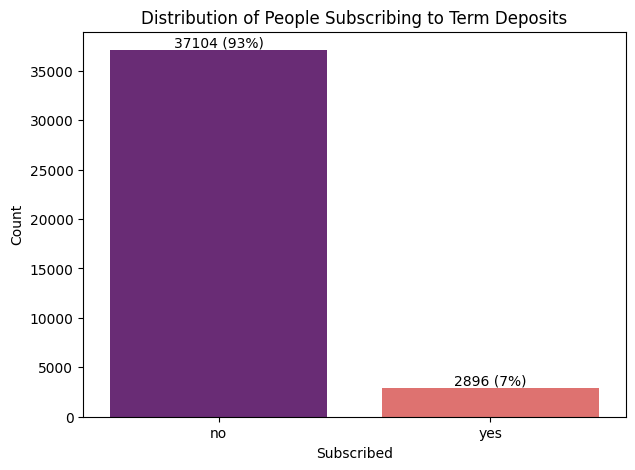

In [ ]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(x='y', data=df, palette='magma')
plt.title('Distribution of People Subscribing to Term Deposits')
plt.xlabel('Subscribed')
plt.ylabel('Count')

# get counts and percentages
abs_values = df['y'].value_counts(ascending=False)
rel_values = df['y'].value_counts(ascending=False, normalize=True).values * 100
labels = [f'{p[0]} ({p[1]:.0f}%)' for p in zip(abs_values, rel_values)]

# Add labels to the bars using ax.annotate
for i, p in enumerate(ax.patches):
    ax.annotate(labels[i], (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

### Categorical features

In [ ]:
sns.color_palette('magma')

[(0.135053, 0.068391, 0.315),
 (0.372116, 0.092816, 0.499053),
 (0.594508, 0.175701, 0.501241),
 (0.828886, 0.262229, 0.430644),
 (0.973381, 0.46152, 0.361965),
 (0.997341, 0.733545, 0.505167)]

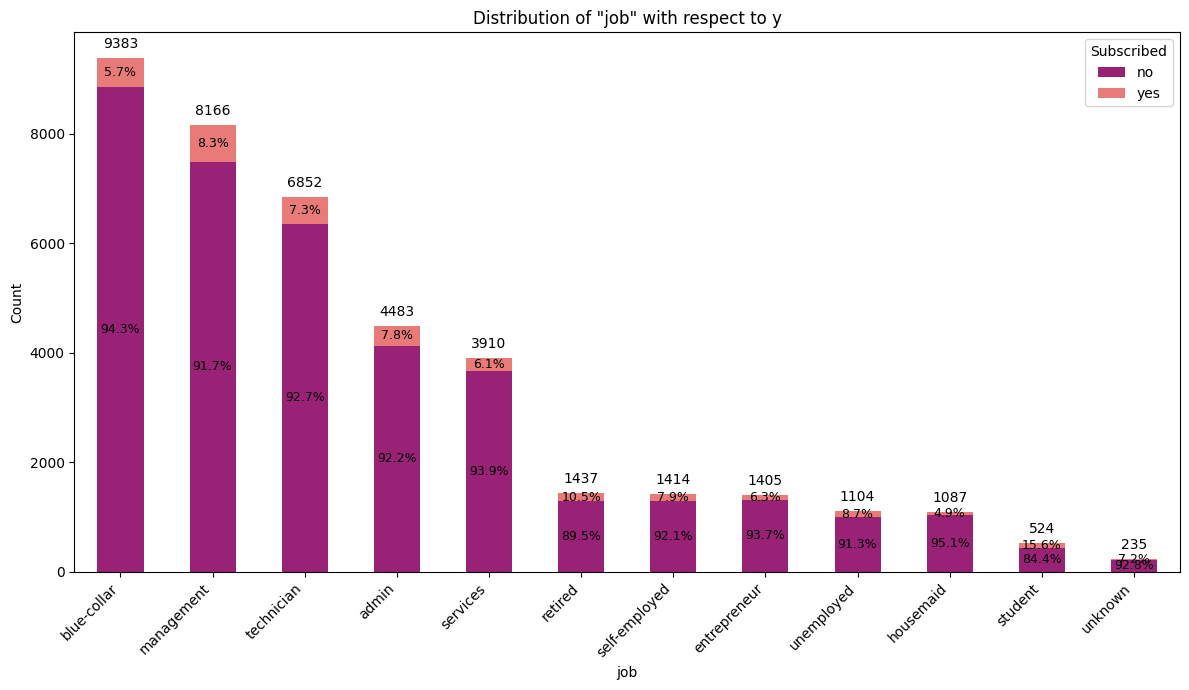

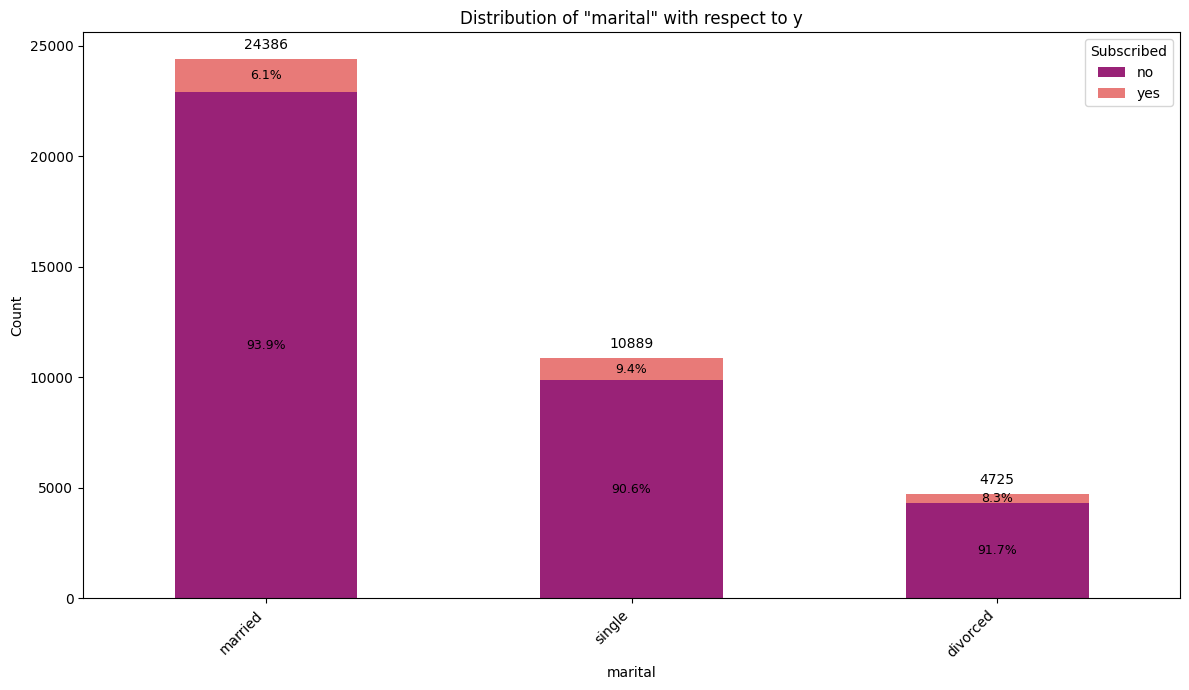

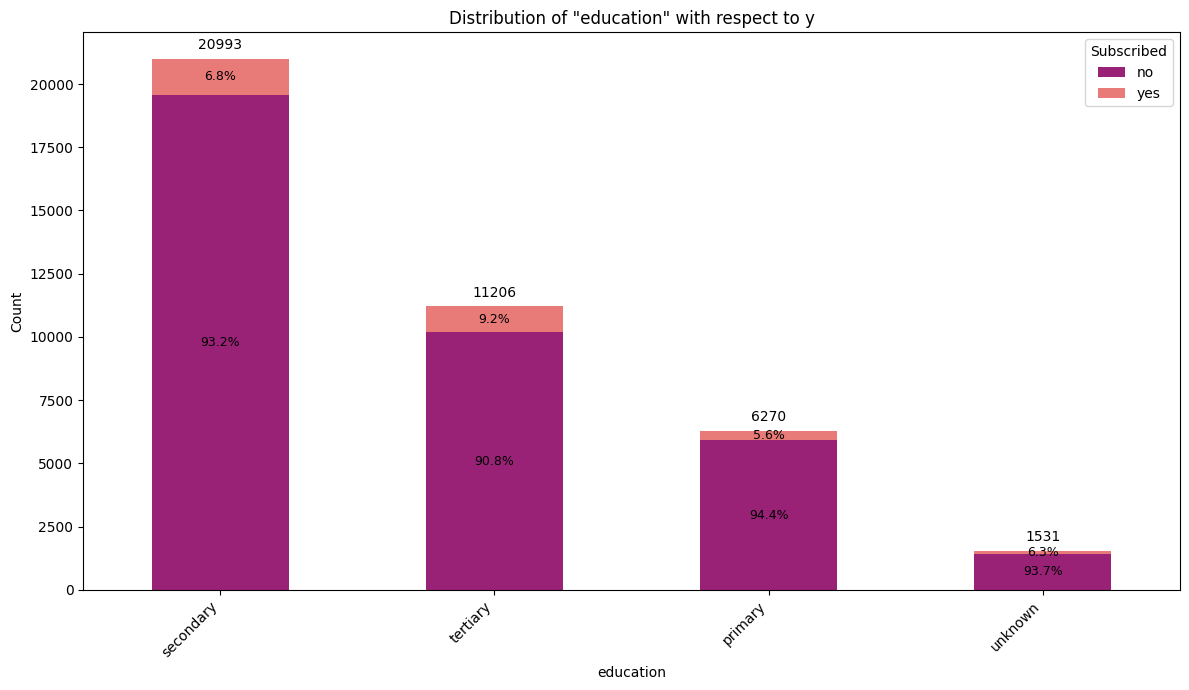

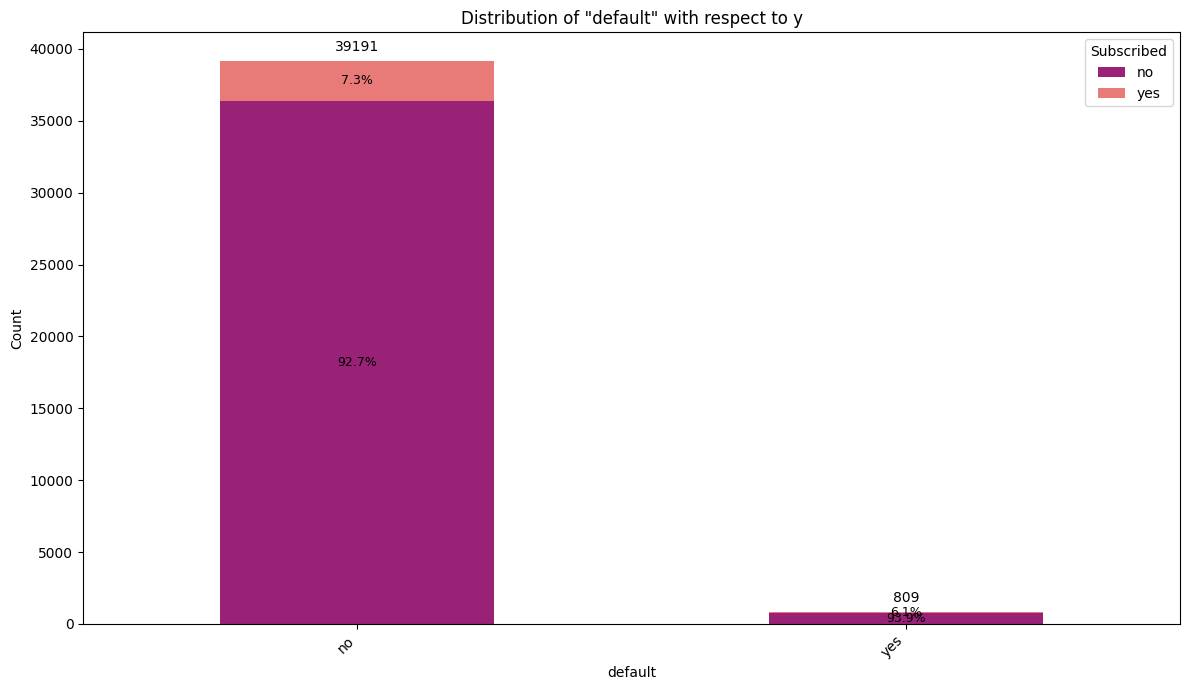

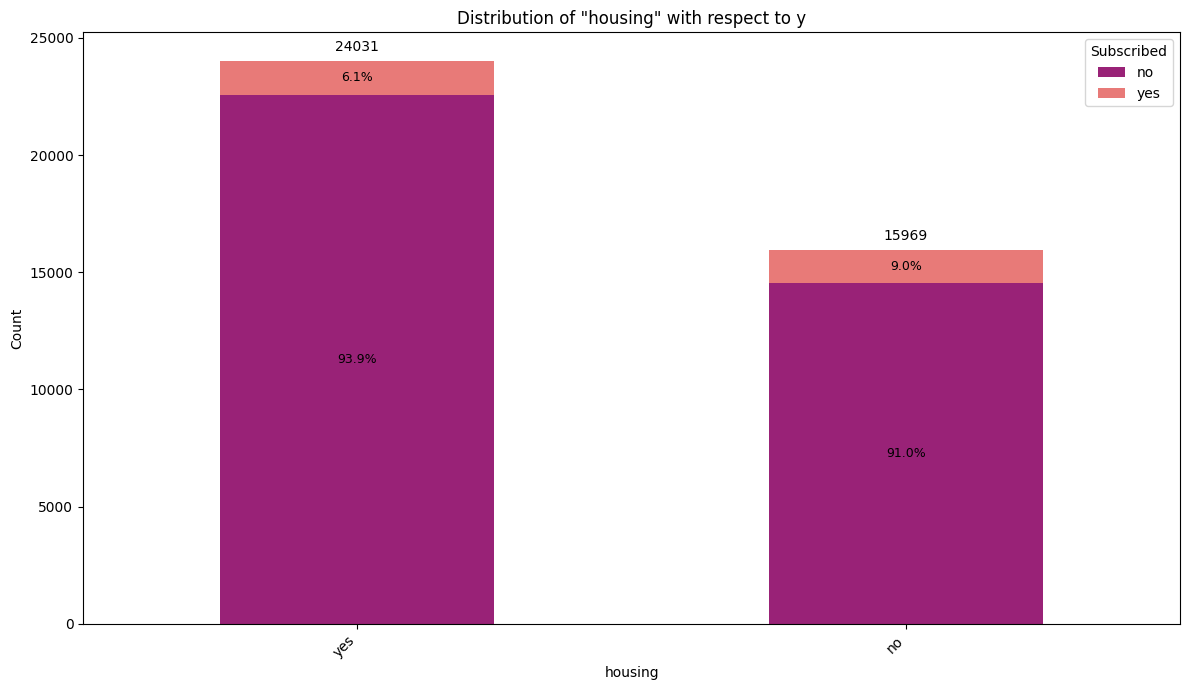

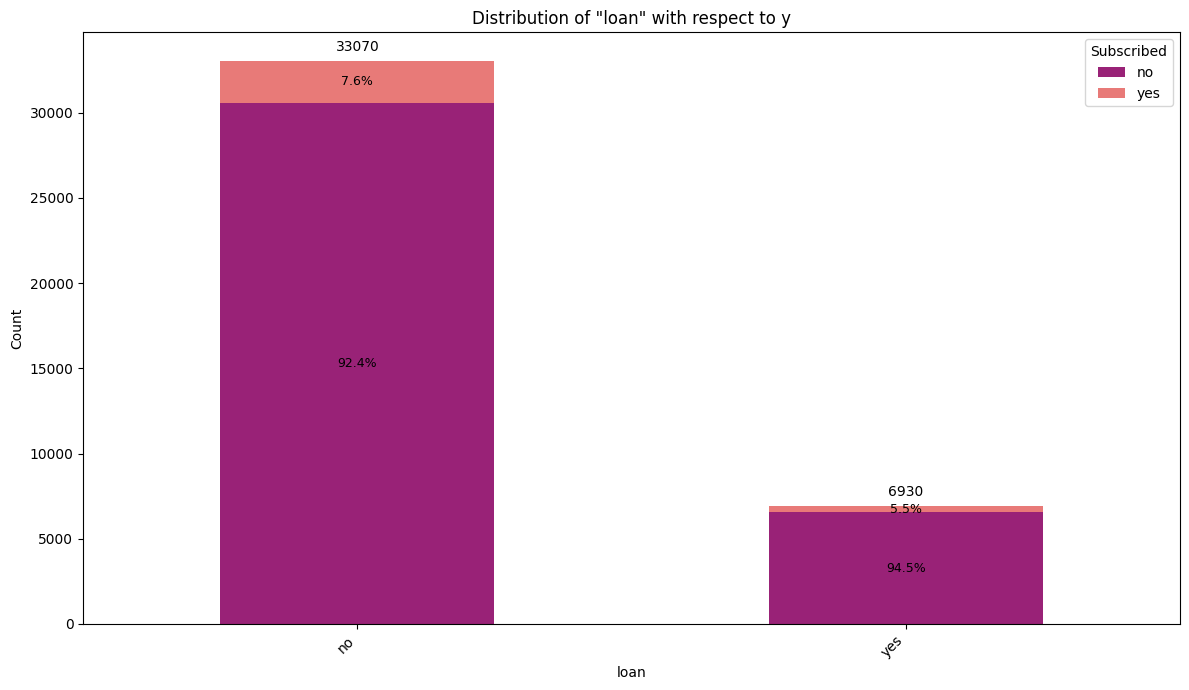

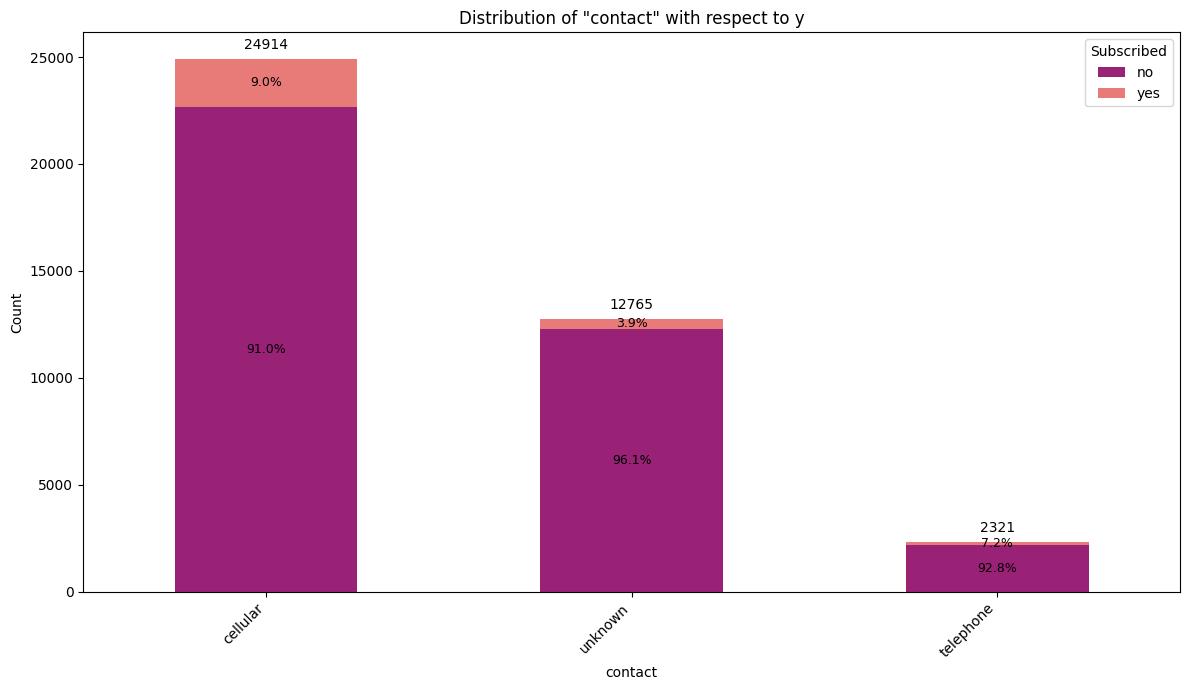

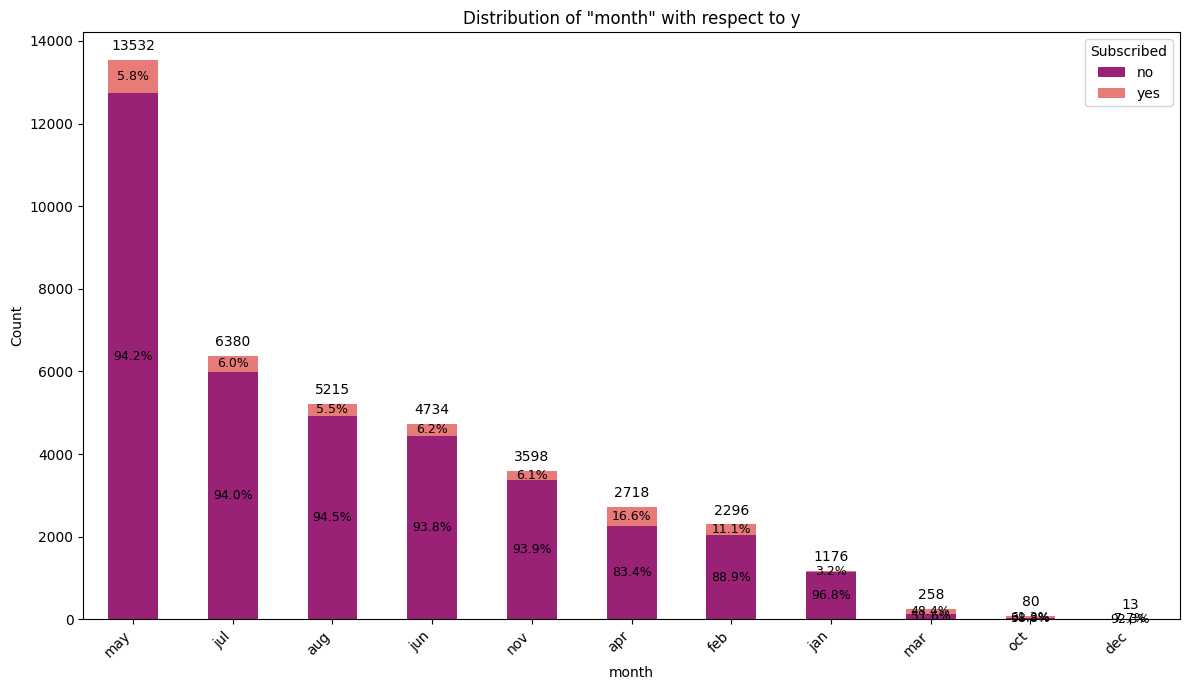

In [ ]:
# Quick look at CATEGORICAL FEATURES

categorical_cols = df.select_dtypes(include='object').columns.tolist()
if 'y' in categorical_cols:
    categorical_cols.remove('y')

for col in categorical_cols:
    plt.figure(figsize=(12, 7))

    # Create a crosstab to get counts of 'yes' and 'no' for each category
    crosstab_df = pd.crosstab(df[col], df['y'], normalize=False)

    # Ensure 'no' and 'yes' columns exist, even if one is empty for a category
    if 'no' not in crosstab_df.columns: crosstab_df['no'] = 0
    if 'yes' not in crosstab_df.columns: crosstab_df['yes'] = 0

    # Reorder columns to ensure 'no' is below 'yes' if that's the desired stacking order
    crosstab_df = crosstab_df[['no', 'yes']]

    # Sort categories by total count (sum of 'no' and 'yes') for better visualization
    crosstab_df['total'] = crosstab_df.sum(axis=1)
    crosstab_df = crosstab_df.sort_values(by='total', ascending=False)

    # Plot as a stacked bar chart
    ax = crosstab_df.drop('total', axis=1).plot(kind='bar', stacked=True, color=['#992277', '#e87a78'], ax=plt.gca())

    plt.title(f'Distribution of "{col}" with respect to y')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Subscribed')

    # Add labels to each section of the stacked bars (percentages)
    for container_idx, container in enumerate(ax.containers):
        for patch_idx, patch in enumerate(container.patches):
            height = patch.get_height()
            x, y = patch.get_xy()
            width = patch.get_width()

            if height > 0: # Only label if there is a bar segment
                # The x-category name corresponding to this patch
                x_category = crosstab_df.index[patch_idx]

                # Total height of the stacked bar for this x_category
                total_of_stacked_bar = crosstab_df.loc[x_category, 'total']

                if total_of_stacked_bar > 0:
                    percentage = (height / total_of_stacked_bar) * 100
                    label_text = f'{percentage:.1f}%'
                else:
                    label_text = '' # Hide label if segment height is 0

                # Position the label in the center of the bar segment
                ax.annotate(label_text,
                            (x + width / 2., y + height / 2.),
                            ha='center', va='center', fontsize=9, color='black')

    # Add total counts at the top of the stacked bars
    for i, (category, total_value) in enumerate(crosstab_df['total'].items()):
        # Find the x-position for the top of this stacked bar
        # Use the x-position of the 'no' bar segment (container_idx=0) for this category
        if i < len(ax.containers[0].patches):
            x_center = ax.containers[0].patches[i].get_x() + ax.containers[0].patches[i].get_width() / 2.

            # Place the total value label slightly above the stacked bar
            ax.annotate(f'{int(total_value)}',
                        (x_center, total_value), # x at center of bar, y at top of bar
                        ha='center', va='bottom', fontsize=10, color='black',
                        xytext=(0, 5), # Offset text slightly above the bar
                        textcoords='offset points')

    plt.tight_layout()
    plt.show()

#### Subscribers analysis
X-axis is in the same order as the main dataset

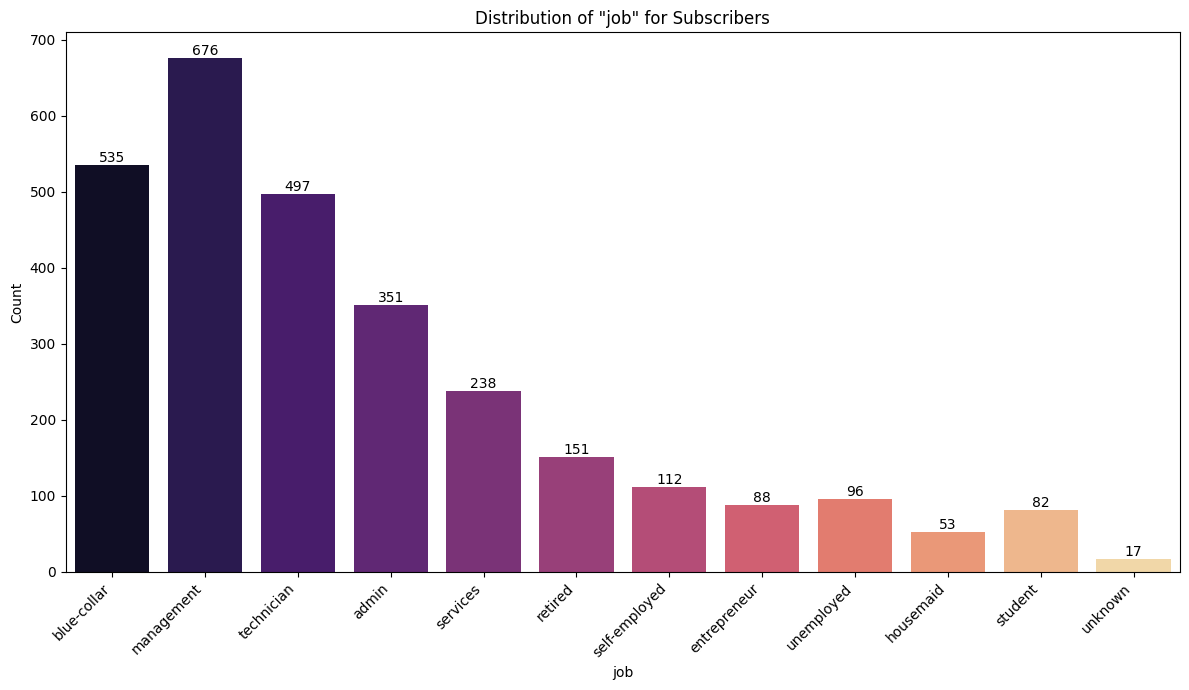

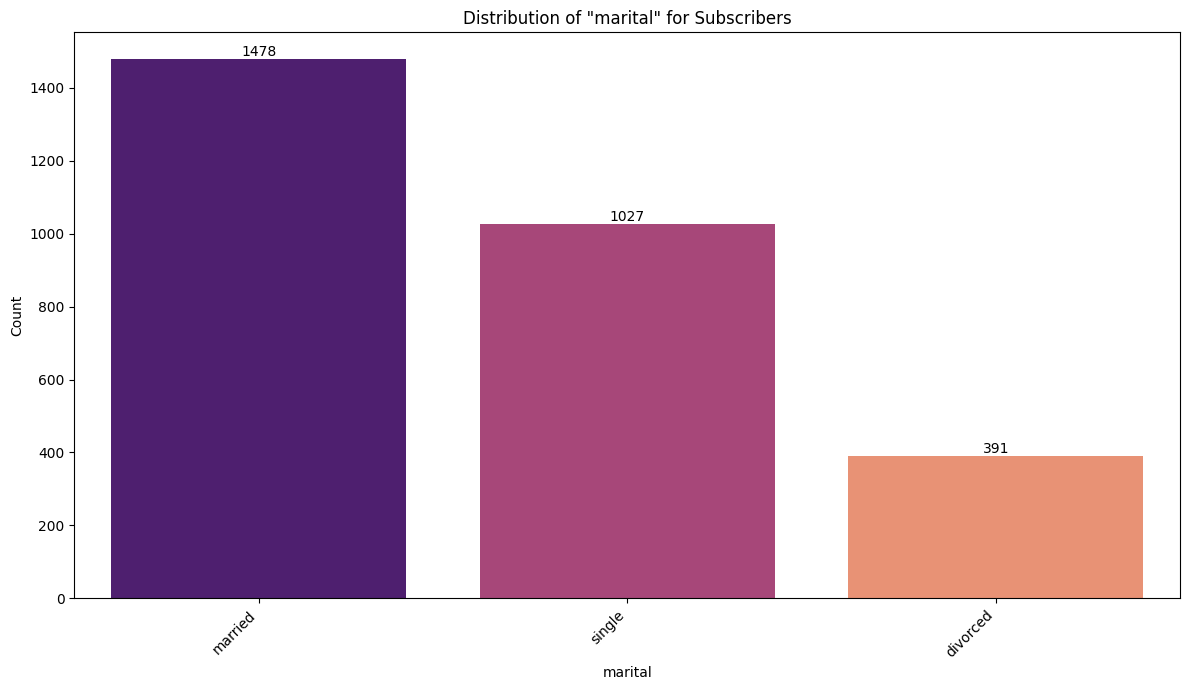

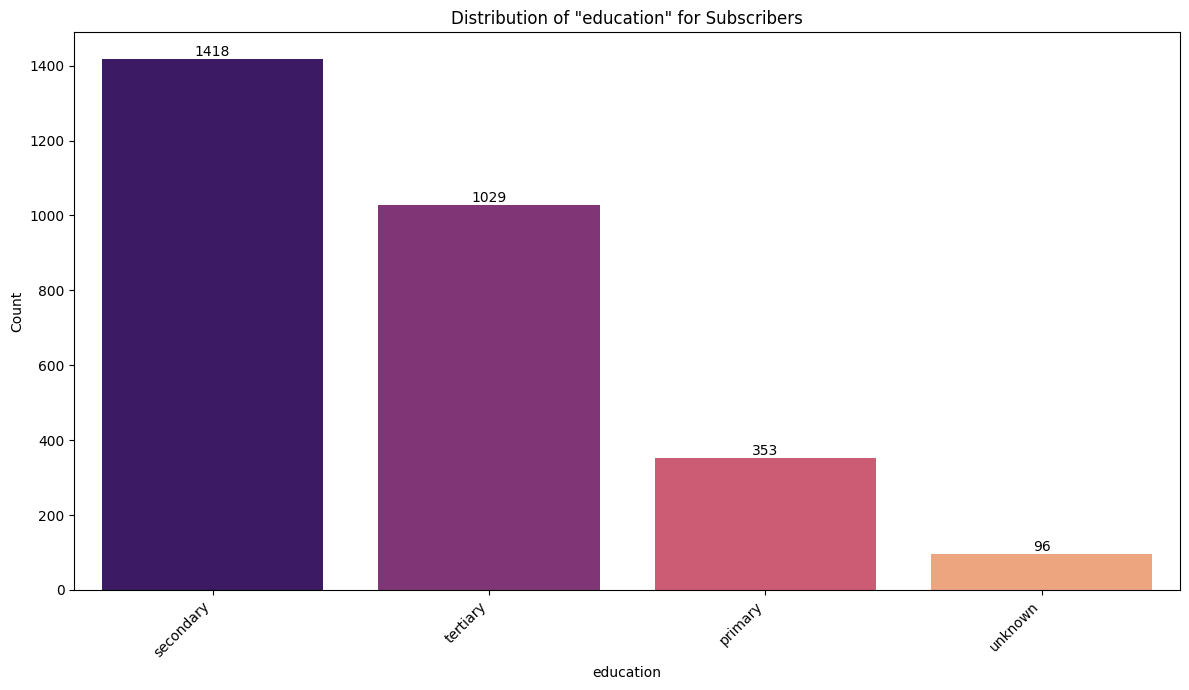

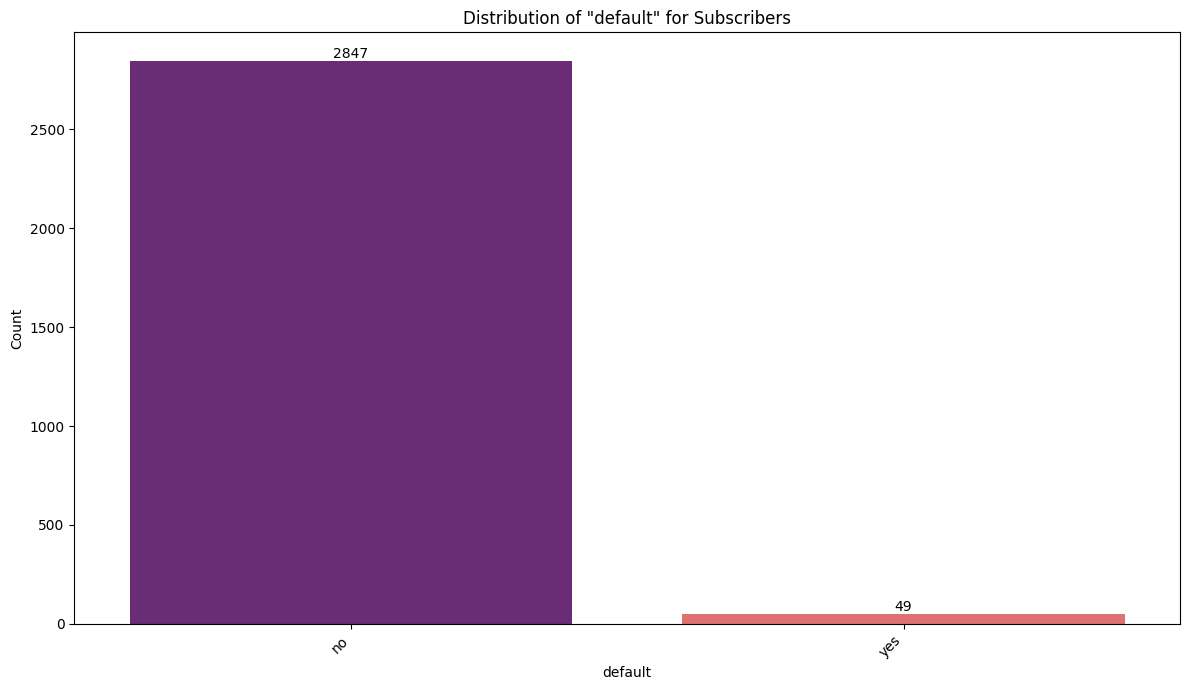

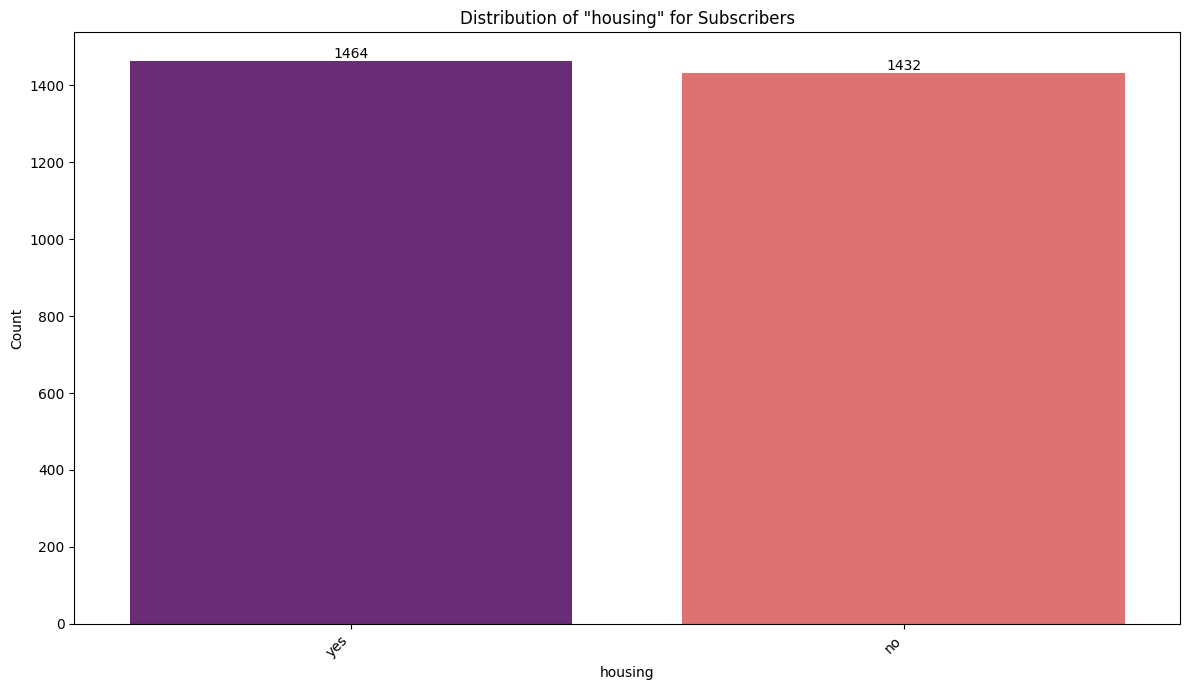

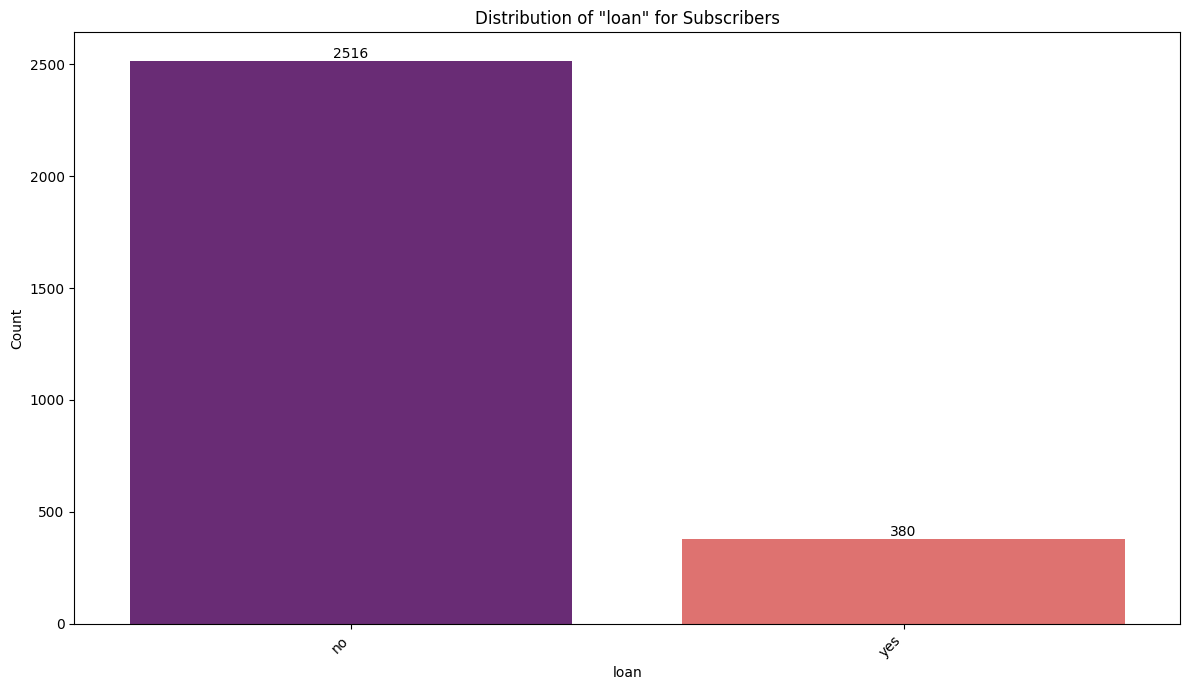

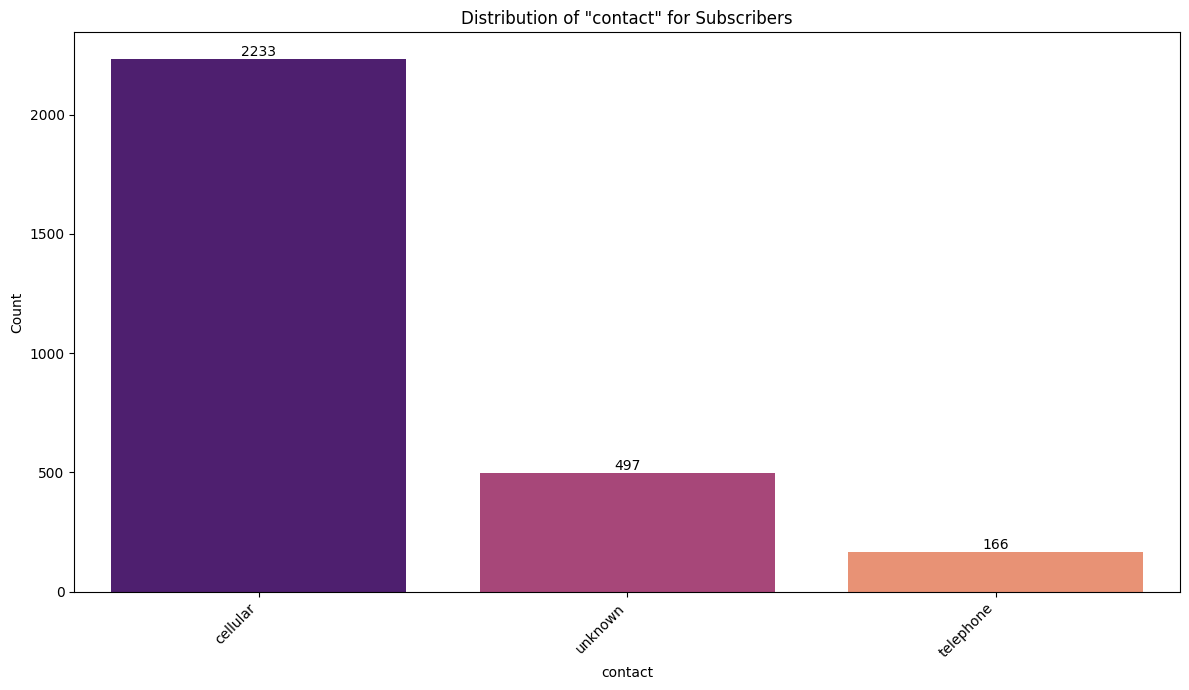

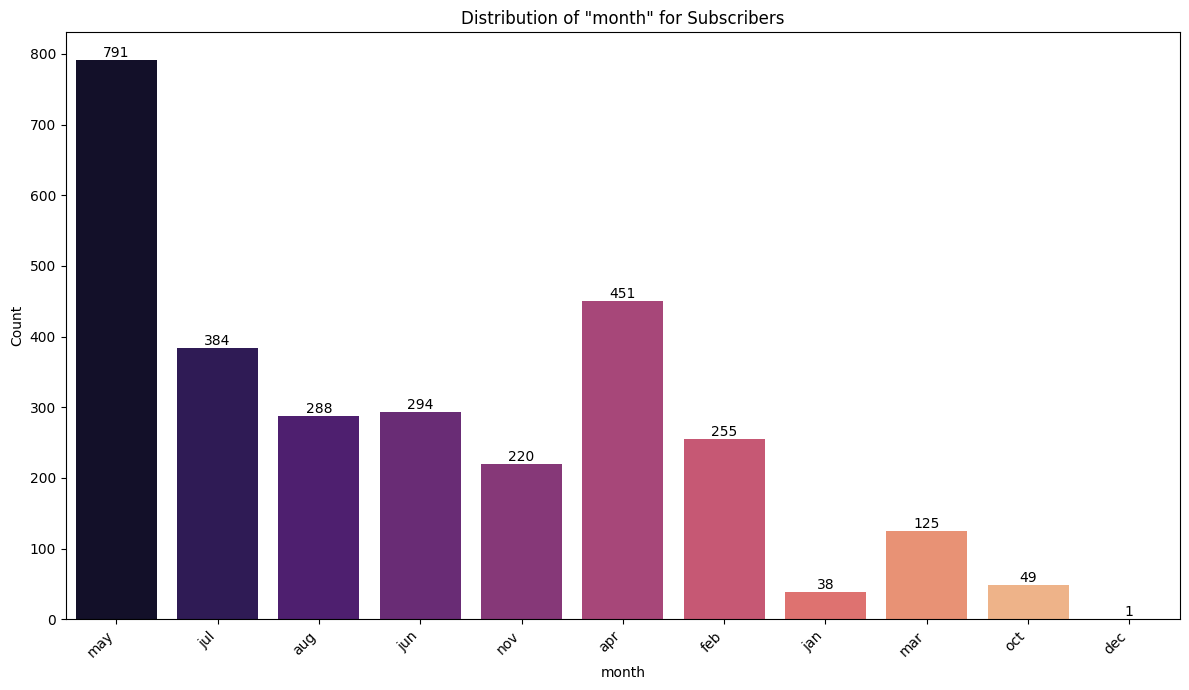

In [ ]:
df_subs = df[df['y']=='yes']

for col in categorical_cols:
    plt.figure(figsize=(12, 7))
    ax = sns.countplot(x=col, data=df_subs, order=df[col].value_counts(ascending=False).index,palette='magma')
    plt.title(f'Distribution of "{col}" for Subscribers')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')

    # Add total counts at the top of the bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', label_type='edge')

    plt.tight_layout()
    plt.show()

note april and march

### Numerical features
start by encoding y and month

In [ ]:
#encode month
df_encoded = df.copy()
df_encoded['month_encoded'] = df_encoded['month'].str.lower().map({
    'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'may': 5, 'jun': 6,
    'jul': 7, 'aug': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12
})

df_encoded['y_encoded'] = df_encoded['y'].apply(lambda x: 1 if x == 'yes' else 0)
# drop y
df_encoded = df_encoded.drop('y', axis=1)

numerical_cols = df_encoded.select_dtypes(include=['int64', 'float64']).columns.tolist()

#redo subscribers dataframe
df_encoded_subs = df_encoded[df_encoded['y_encoded']==1].drop(['y_encoded'], axis=1)

#### Histograms

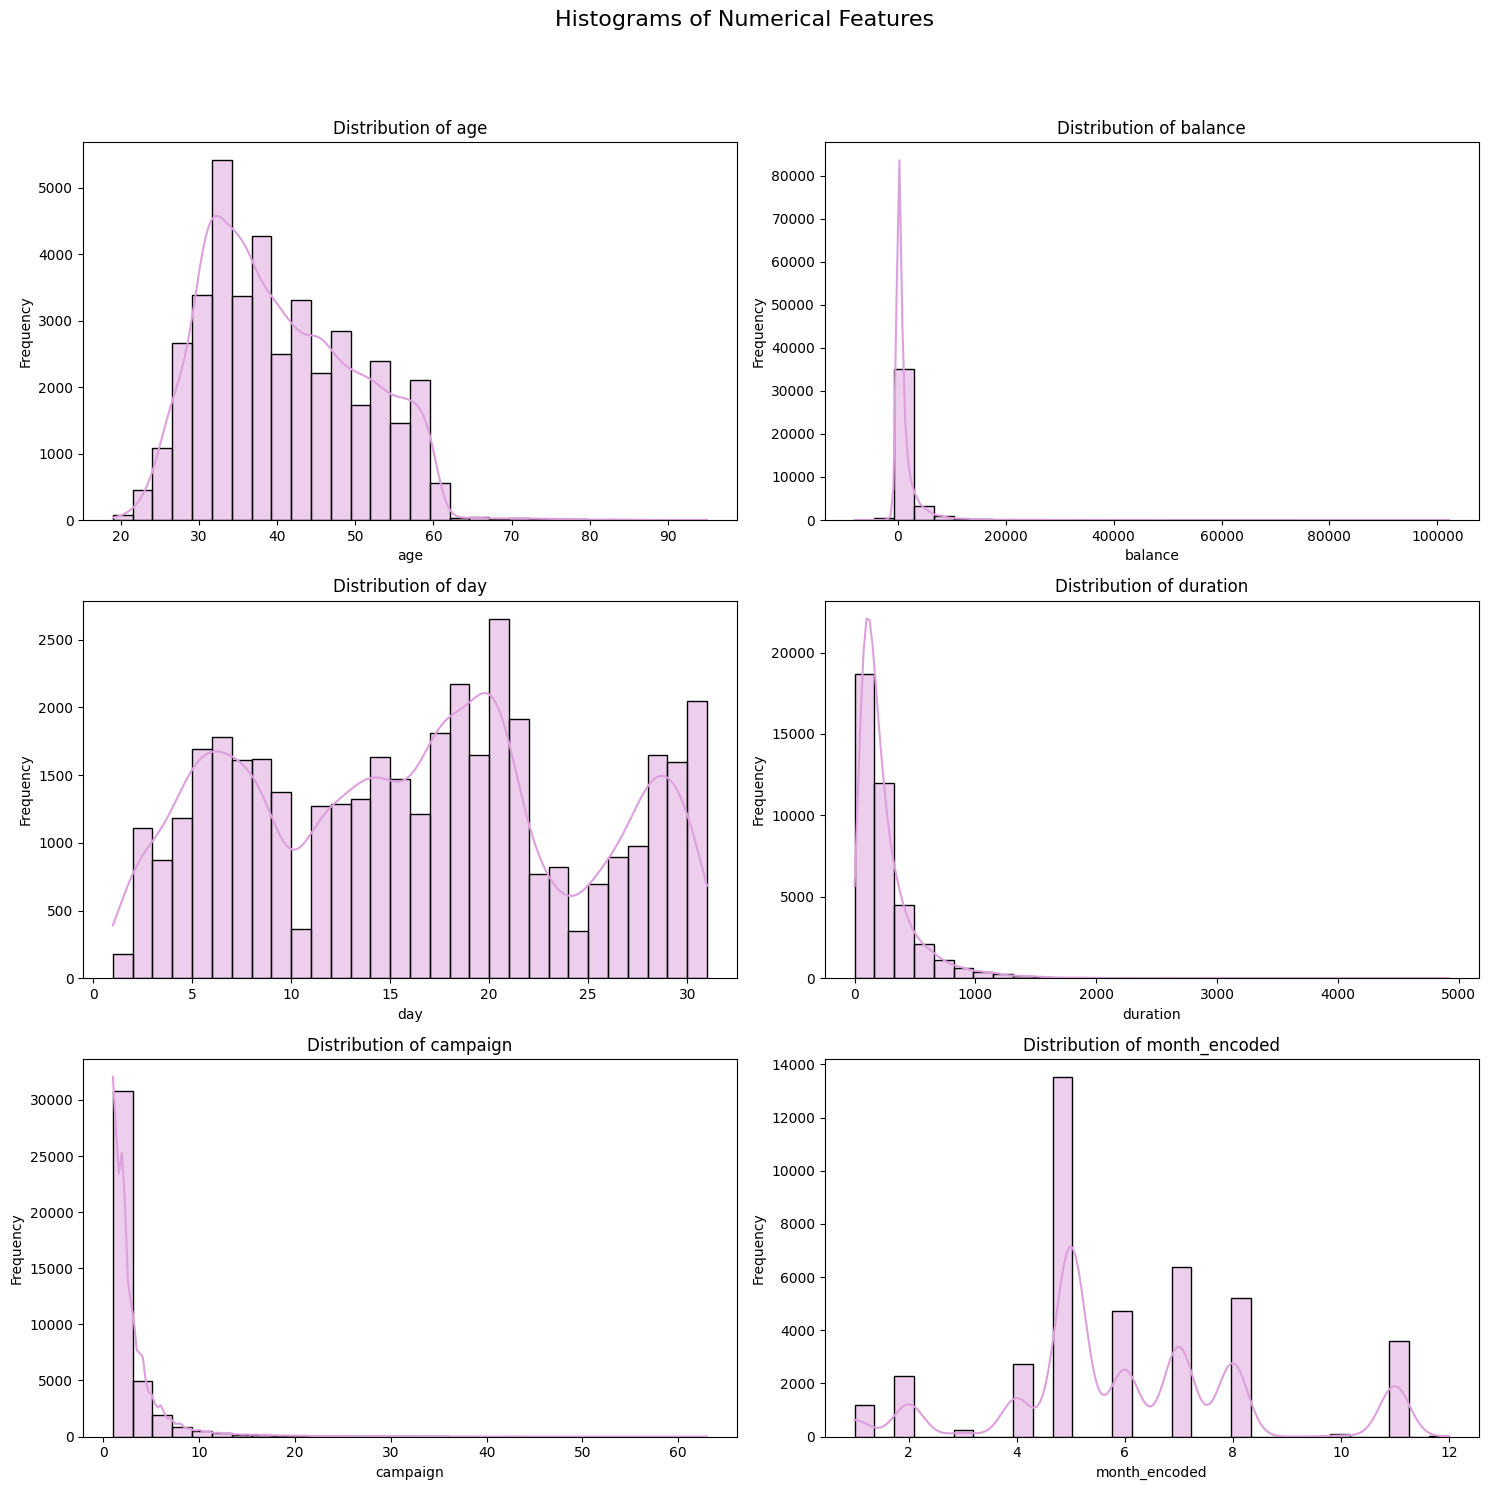

In [ ]:
# plot histograms

fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes = axes.flatten()

cols = ['age', 'balance', 'day', 'duration', 'campaign', 'month_encoded']
for i, col in enumerate(cols):
    sns.histplot(data=df_encoded, x=col, kde=True, bins=30, edgecolor='black', color='plum', ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.suptitle('Histograms of Numerical Features', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

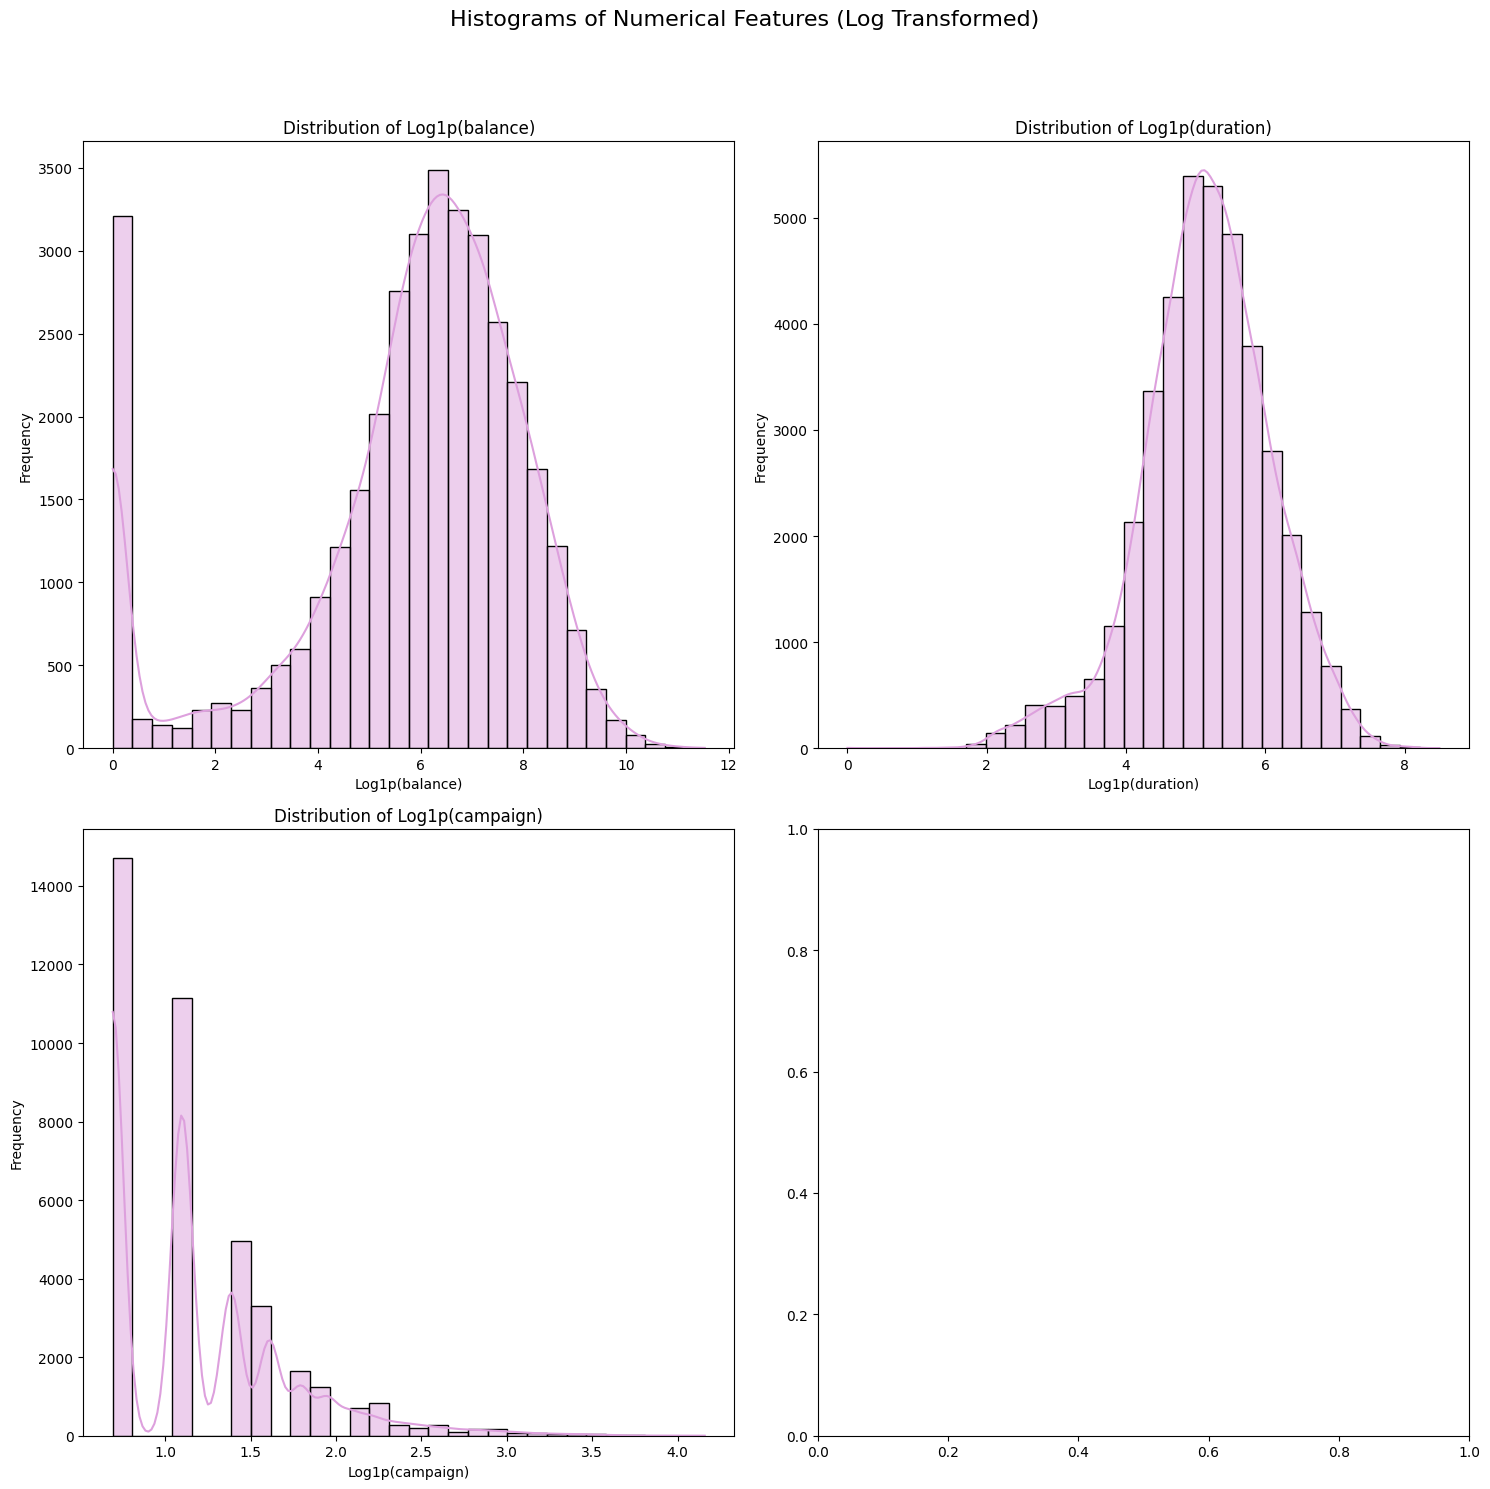

In [ ]:
# plot histograms of campaign and balance as a log

fig, axes = plt.subplots(2, 2, figsize=(15, 15))
axes = axes.flatten()

cols_log = ['balance', 'duration', 'campaign']
for i, col in enumerate(cols_log):
    # Apply log1p transformation
    plot_data = np.log1p(df_encoded[col])

    sns.histplot(x=plot_data, kde=True, bins=30, edgecolor='black', color='plum', ax=axes[i])
    axes[i].set_title(f'Distribution of Log1p({col})')
    axes[i].set_xlabel(f'Log1p({col})')
    axes[i].set_ylabel('Frequency')

plt.suptitle('Histograms of Numerical Features (Log Transformed)', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

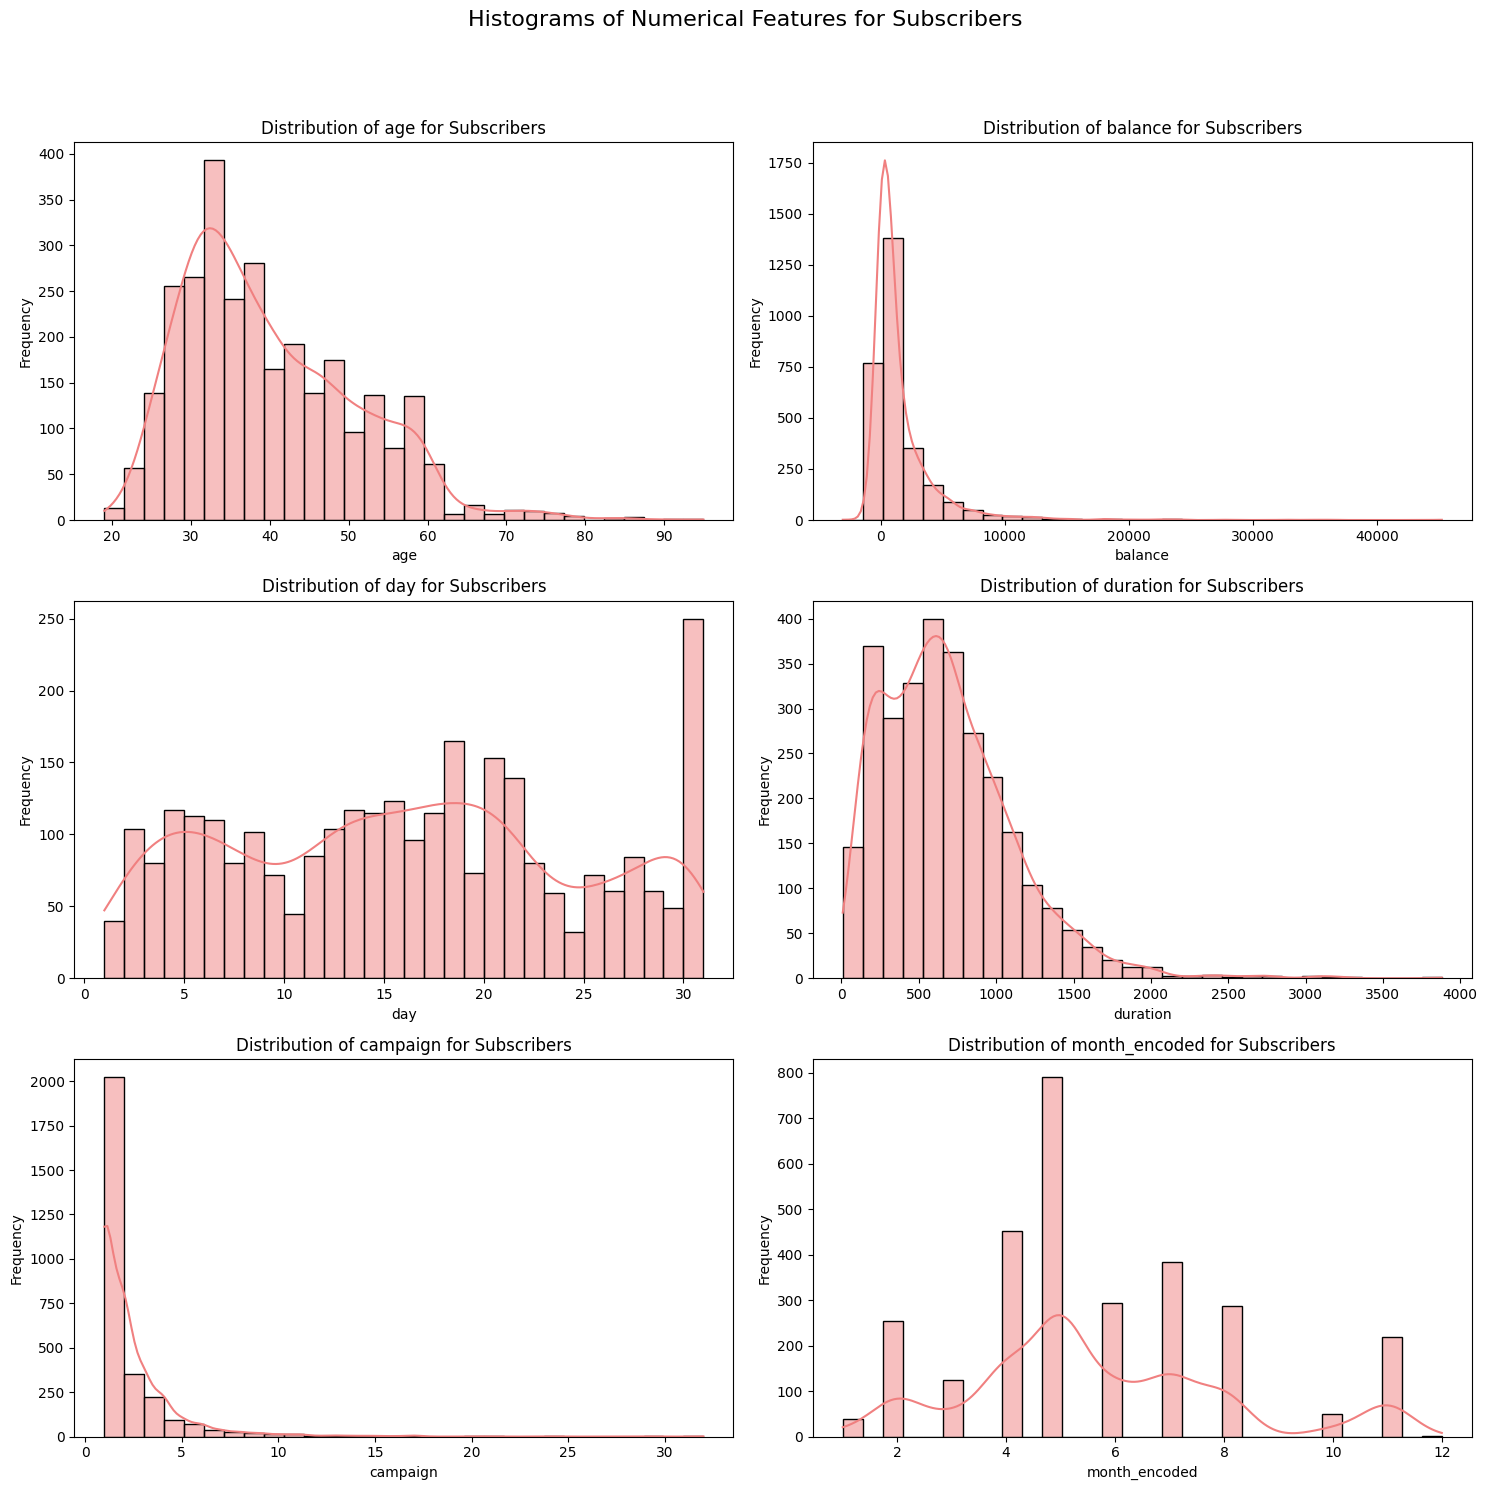

In [ ]:
# plot histograms of subscribers

fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes = axes.flatten()

cols = ['age', 'balance', 'day', 'duration', 'campaign', 'month_encoded']
for i, col in enumerate(cols):
    sns.histplot(data=df_encoded_subs, x=col, kde=True, bins=30, edgecolor='black', color='lightcoral', ax=axes[i])
    axes[i].set_title(f'Distribution of {col} for Subscribers')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.suptitle('Histograms of Numerical Features for Subscribers', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

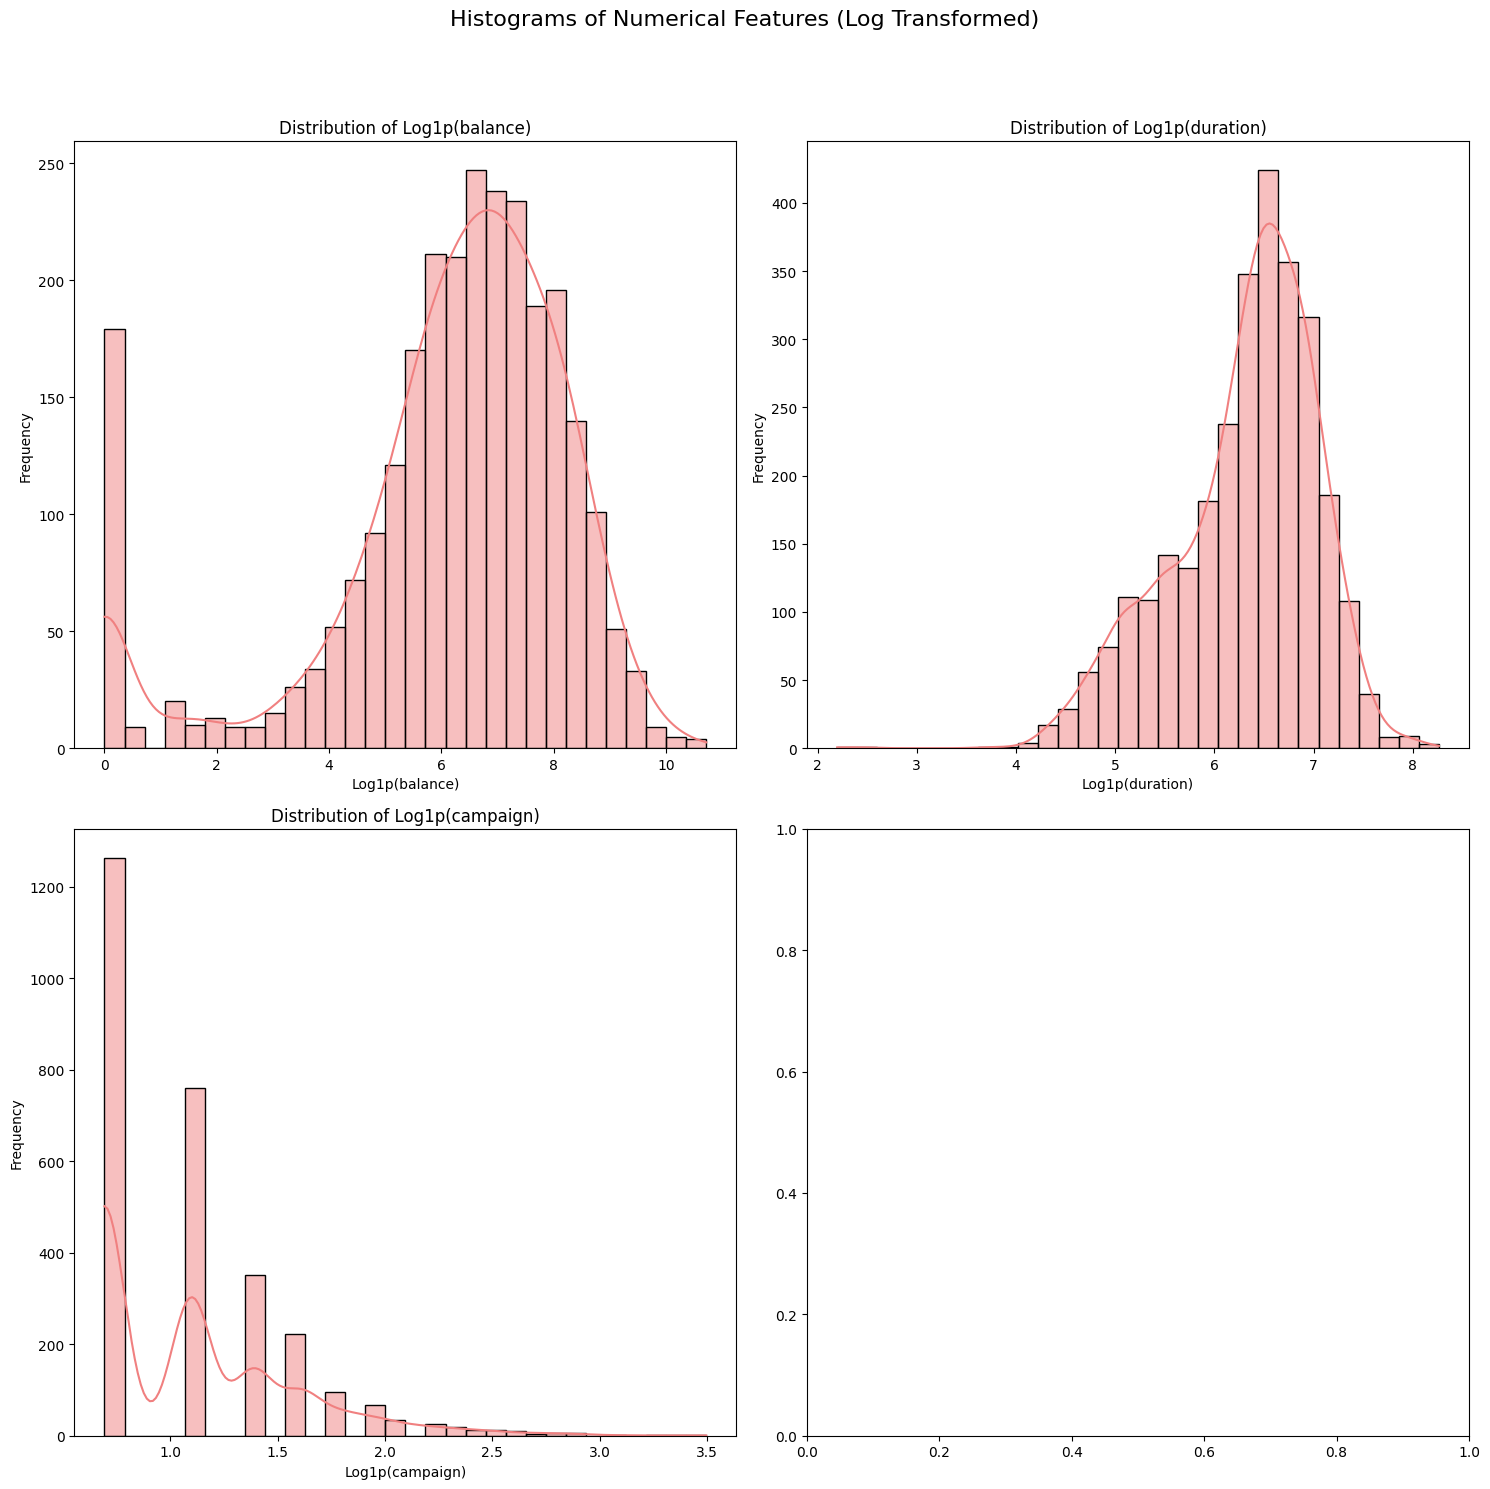

In [ ]:
# plot histograms of campaign and balance as a log

fig, axes = plt.subplots(2, 2, figsize=(15, 15))
axes = axes.flatten()

cols_log = ['balance', 'duration', 'campaign']
for i, col in enumerate(cols_log):
    # Apply log1p transformation
    plot_data = np.log1p(df_encoded_subs[col])

    sns.histplot(x=plot_data, kde=True, bins=30, edgecolor='black', color='lightcoral', ax=axes[i])
    axes[i].set_title(f'Distribution of Log1p({col})')
    axes[i].set_xlabel(f'Log1p({col})')
    axes[i].set_ylabel('Frequency')

plt.suptitle('Histograms of Numerical Features (Log Transformed)', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

This describes the company's successful attempts

#### Box plots

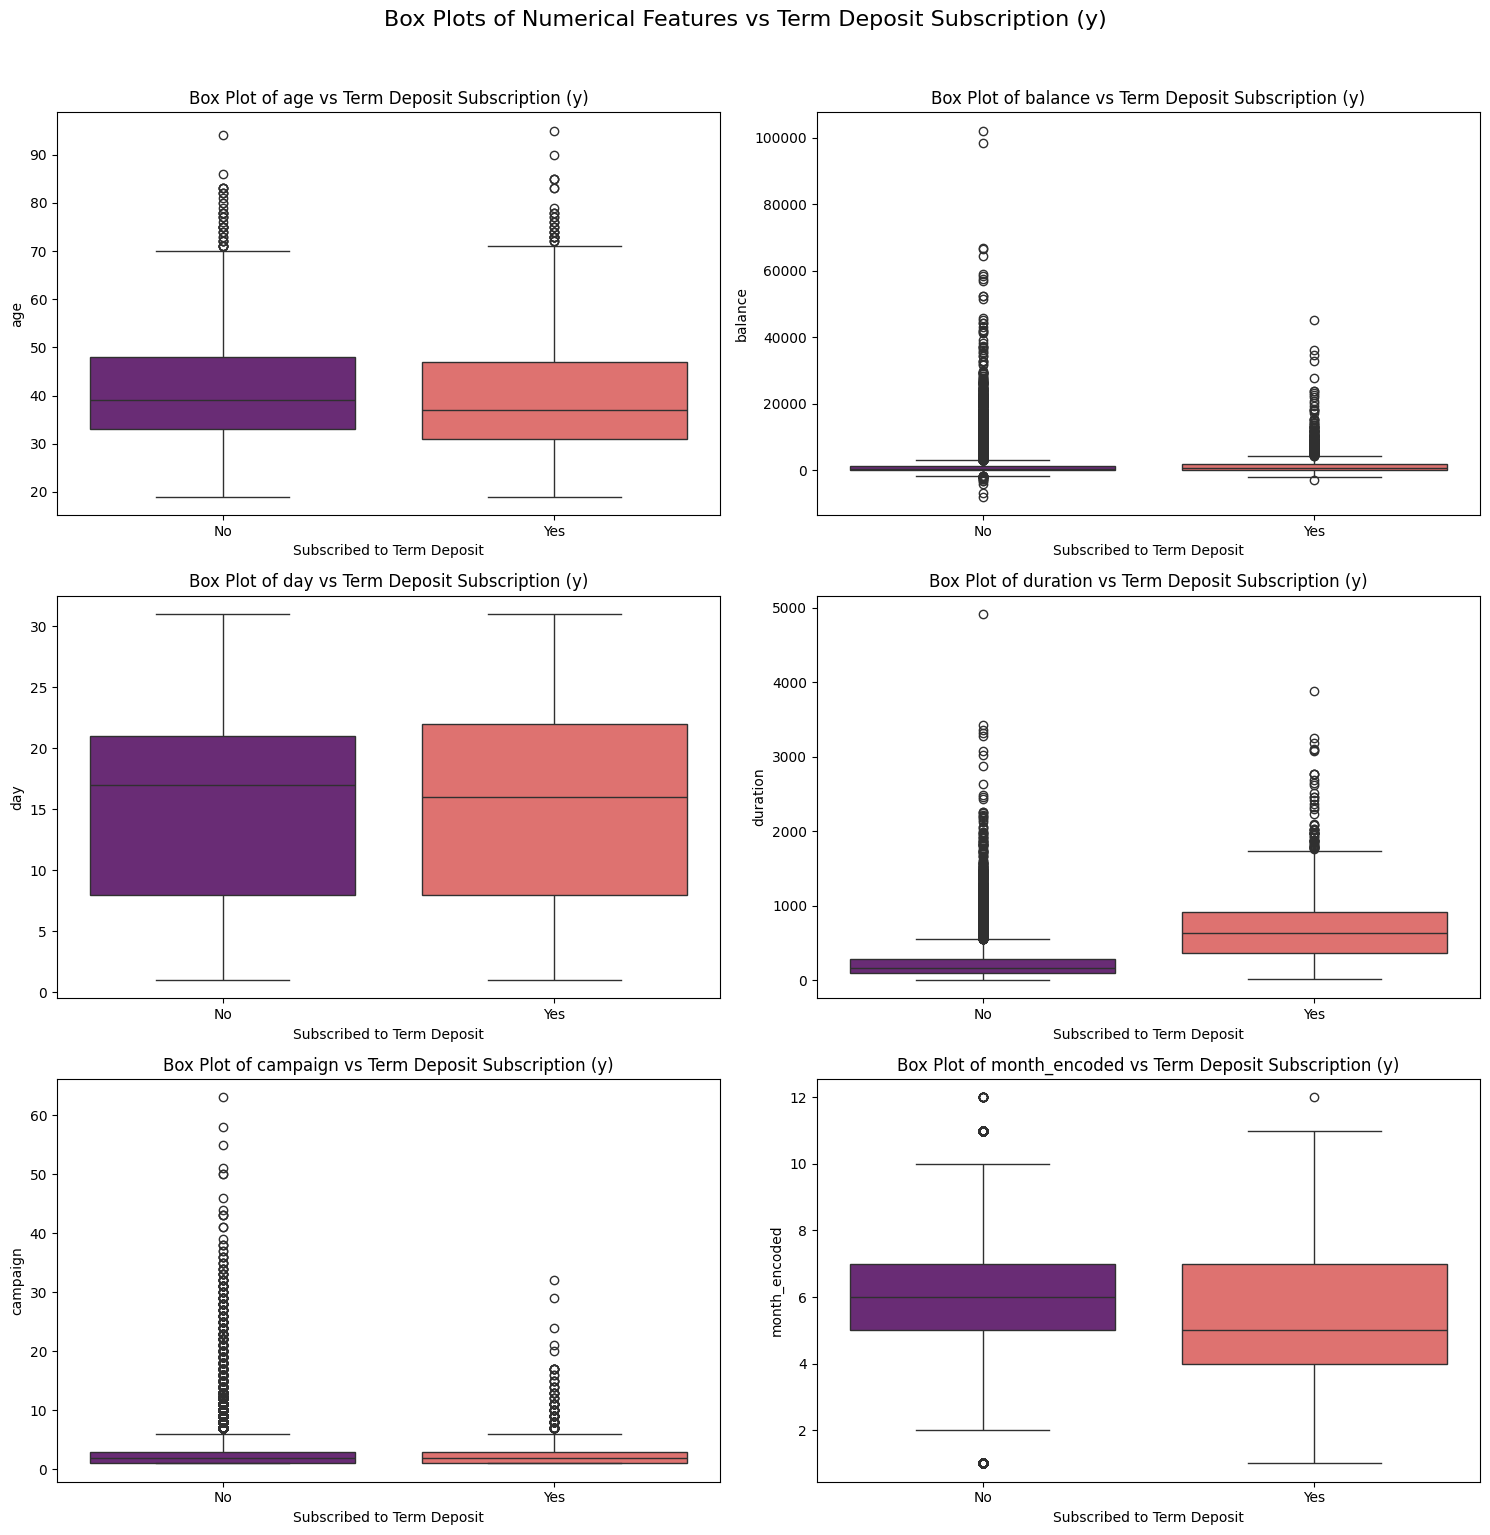

In [ ]:
# Box Plots for Numerical Features vs Target Variable 'y'
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes = axes.flatten()

cols = ['age', 'balance', 'day', 'duration', 'campaign', 'month_encoded']
for i, col in enumerate(cols):
    sns.boxplot(x='y_encoded', y=col, data=df_encoded, palette='magma', ax=axes[i])
    axes[i].set_title(f'Box Plot of {col} vs Term Deposit Subscription (y)')
    axes[i].set_xlabel('Subscribed to Term Deposit')
    axes[i].set_ylabel(col)
    axes[i].set_xticklabels(['No', 'Yes'])

plt.suptitle('Box Plots of Numerical Features vs Term Deposit Subscription (y)', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

people say no when contacted too late. duration of the call is a sign they will say yes

#### Pearson Correlation

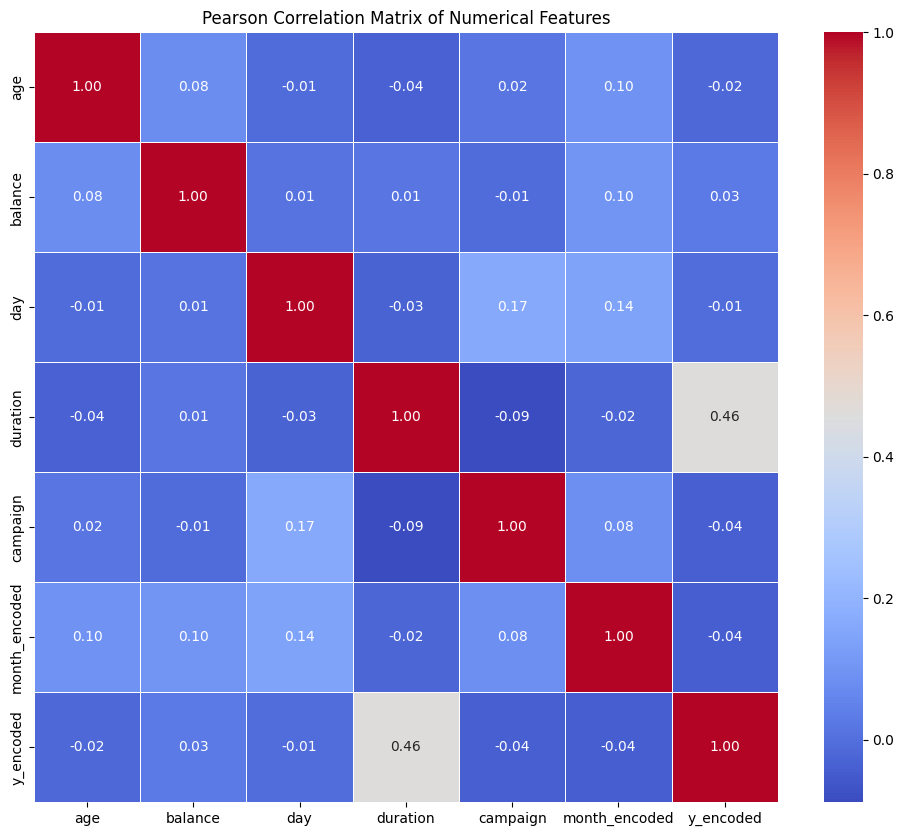

In [ ]:
# Include only numerical columns for correlation matrix
correlation_matrix = df_encoded[numerical_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Pearson Correlation Matrix of Numerical Features')
plt.show()


#### Pair plot

In [ ]:
# sns.pairplot(df_encoded[numerical_cols], hue='y_encoded', diag_kind='kde', palette='magma')
# plt.suptitle('Pair Plot of Selected Numerical Features with Target', y=1.02)
# plt.show()

In [ ]:
# sns.pairplot(df_encoded_subs[cols], diag_kind='kde', palette='magma')
# plt.suptitle('Pair Plot of Selected Numerical Features for subscribers', y=1.02)
# plt.show()

# Modelling

#### Setup (seed, import packages)

In [ ]:
from lazypredict.Supervised import LazyClassifier
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn import tree

from imblearn.combine import SMOTEENN, SMOTETomek
from imblearn.under_sampling import RandomUnderSampler

In [ ]:
# set SEED
seed = 8

#### preprocessing (prepare / OneHot encode the data)

In [ ]:
# OneHot encode
df_onehot = pd.get_dummies(df, columns=['y', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month'], drop_first=True)
df_onehot.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 37 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   age                  40000 non-null  int64
 1   balance              40000 non-null  int64
 2   day                  40000 non-null  int64
 3   duration             40000 non-null  int64
 4   campaign             40000 non-null  int64
 5   y_yes                40000 non-null  bool 
 6   job_blue-collar      40000 non-null  bool 
 7   job_entrepreneur     40000 non-null  bool 
 8   job_housemaid        40000 non-null  bool 
 9   job_management       40000 non-null  bool 
 10  job_retired          40000 non-null  bool 
 11  job_self-employed    40000 non-null  bool 
 12  job_services         40000 non-null  bool 
 13  job_student          40000 non-null  bool 
 14  job_technician       40000 non-null  bool 
 15  job_unemployed       40000 non-null  bool 
 16  job_unknown          4

In [ ]:
# Prepare the data for modelling

# Define Stage 0 features
X_stage0 = df_onehot.copy()
drop_cols = ['y', 'day', 'duration', 'campaign', 'contact', 'month']
for col in df_onehot.columns:
    for c in drop_cols:
        if col.startswith(c):
            X_stage0.drop(col, axis=1, inplace=True)

# Define Target
y_classification = df_onehot['y_yes']

# perform train/test split
X_train, X_test, y_train, y_test = train_test_split(X_stage0, y_classification, test_size=0.3, random_state=seed, stratify=y_classification)

print(f"Features shape: {X_stage0.shape}")
print()
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print()
print(f"Classification target distribution:\n{y_classification.value_counts(normalize=True)}\n{y_classification.value_counts(normalize=False)}")
print(f'\ny_train classification target distribution:\n{y_train.value_counts(normalize=True)}\n{y_train.value_counts(normalize=False)}')
print(f'\ny_test classification target distribution:\n{y_test.value_counts(normalize=True)}\n{y_test.value_counts(normalize=False)}')

Features shape: (40000, 21)

X_train shape: (28000, 21)
X_test shape: (12000, 21)

Classification target distribution:
y_yes
False    0.9276
True     0.0724
Name: proportion, dtype: float64
y_yes
False    37104
True      2896
Name: count, dtype: int64

y_train classification target distribution:
y_yes
False    0.927607
True     0.072393
Name: proportion, dtype: float64
y_yes
False    25973
True      2027
Name: count, dtype: int64

y_test classification target distribution:
y_yes
False    0.927583
True     0.072417
Name: proportion, dtype: float64
y_yes
False    11131
True       869
Name: count, dtype: int64


#### resample the training data using SMOTE-ENN, SMOTE-TOMEK, and Random Under Sampler

In [ ]:
# Create copies of training data for each resampling method
X_train_enn, y_train_enn = X_train.copy(), y_train.copy()
X_train_tomek, y_train_tomek = X_train.copy(), y_train.copy()
X_train_rus, y_train_rus = X_train.copy(), y_train.copy()

# Apply SMOTE-ENN
smote_enn = SMOTEENN(random_state=seed)
X_train_enn, y_train_enn = smote_enn.fit_resample(X_train_enn, y_train_enn)


# Apply SMOTE-TOMEK
smote_tomek = SMOTETomek(random_state=seed)
X_train_tomek, y_train_tomek = smote_tomek.fit_resample(X_train_tomek, y_train_tomek)


# Apply RandomUnderSampler
rus = RandomUnderSampler(random_state=seed)
X_train_rus, y_train_rus = rus.fit_resample(X_train_rus, y_train_rus)


In [ ]:
# Print some stuff
print(f"Original training data shape (X, y): {X_train.shape}, {y_train.shape}")
print(f"Original training target distribution:\n{y_train.value_counts(normalize=True)}")
print(y_train.value_counts(normalize=False))

print(f"\nSMOTE-ENN resampled shape (X, y): {X_train_enn.shape}, {y_train_enn.shape}")
print(f"SMOTE-ENN target distribution:\n{y_train_enn.value_counts(normalize=True)}")
print(y_train_enn.value_counts(normalize=False))

print(f"\nSMOTE-TOMEK resampled shape (X, y): {X_train_tomek.shape}, {y_train_tomek.shape}")
print(f"SMOTE-TOMEK target distribution:\n{y_train_tomek.value_counts(normalize=True)}")
print(y_train_tomek.value_counts(normalize=False))

print(f"\nRandomUnderSampler resampled shape (X, y): {X_train_rus.shape}, {y_train_rus.shape}")
print(f"RandomUnderSampler target distribution:\n{y_train_rus.value_counts(normalize=True)}")
print(y_train_rus.value_counts(normalize=False))

Original training data shape (X, y): (28000, 21), (28000,)
Original training target distribution:
y_yes
False    0.927607
True     0.072393
Name: proportion, dtype: float64
y_yes
False    25973
True      2027
Name: count, dtype: int64

SMOTE-ENN resampled shape (X, y): (32864, 21), (32864,)
SMOTE-ENN target distribution:
y_yes
True     0.604735
False    0.395265
Name: proportion, dtype: float64
y_yes
True     19874
False    12990
Name: count, dtype: int64

SMOTE-TOMEK resampled shape (X, y): (49796, 21), (49796,)
SMOTE-TOMEK target distribution:
y_yes
False    0.5
True     0.5
Name: proportion, dtype: float64
y_yes
False    24898
True     24898
Name: count, dtype: int64

RandomUnderSampler resampled shape (X, y): (4054, 21), (4054,)
RandomUnderSampler target distribution:
y_yes
False    0.5
True     0.5
Name: proportion, dtype: float64
y_yes
False    2027
True     2027
Name: count, dtype: int64


#### Evaluate three tree-based models for SMOTE-ENN data (add logistic regression?)



In [ ]:
# define the classifiers
classifiers = {
    'Decision Tree': DecisionTreeClassifier(random_state=seed),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=seed, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=200, random_state=seed, n_jobs=-1)
}

#initialise the results list
results_enn = []

# Map boolean labels to numerical for ROC AUC calculation
label_mapping = {False: 0, True: 1}

#iterate over each model and evaluate
for name, model in classifiers.items():
    model.fit(X_train_enn, y_train_enn)
    predictions = model.predict(X_test)

    # precision, recall, f1-score, and support
    report = classification_report(y_test, predictions, output_dict=True, zero_division='warn')
    precision = report['True']['precision']
    recall = report['True']['recall']
    f1_score = report['True']['f1-score']
    support = report['True']['support'] # Support for the positive class

    # Convert y_test to numerical for roc_auc_score (y_test is boolean)
    y_test_numeric = y_test.map(label_mapping)
    # predictions are already numerical (0s and 1s), so directly convert to Series
    predictions_numeric = pd.Series(predictions)
    # Use numerical labels for roc_auc_score
    roc_auc = roc_auc_score(y_test_numeric, predictions_numeric)

    # full classification report
    cr = classification_report(y_test, predictions)

    # confusion matrix
    cm = confusion_matrix(y_test, predictions)

    # Append the results_enn to the list

    results_enn.append({
        'Model': name,
        'Precision': precision,
        'Recall': recall,
        'F1 score': f1_score,
        'Support': support,
        'ROC AUC': roc_auc,
        'Classification Report': cr,
        'Confusion Matrix': cm
    })


##### Classification reports and confusion matrices

In [ ]:
#classification report
print('Classification Model Performance:')
results_enn_df = pd.DataFrame(results_enn).sort_values('F1 score', ascending=False)
print(results_enn_df.iloc[:,0:6].round(4))
print()

for idx, row in results_enn_df.iterrows():
    print(f'Classification Report for {row["Model"]}:')
    print(row['Classification Report'])
    print()

Classification Model Performance:
           Model  Precision  Recall  F1 score  Support  ROC AUC
0  Decision Tree     0.1140  0.2681    0.1600    869.0   0.5528
2        XGBoost     0.1163  0.2221    0.1527    869.0   0.5452
1  Random Forest     0.1122  0.1899    0.1411    869.0   0.5363

Classification Report for Decision Tree:
              precision    recall  f1-score   support

       False       0.94      0.84      0.88     11131
        True       0.11      0.27      0.16       869

    accuracy                           0.80     12000
   macro avg       0.53      0.55      0.52     12000
weighted avg       0.88      0.80      0.83     12000


Classification Report for XGBoost:
              precision    recall  f1-score   support

       False       0.93      0.87      0.90     11131
        True       0.12      0.22      0.15       869

    accuracy                           0.82     12000
   macro avg       0.53      0.55      0.53     12000
weighted avg       0.88      0.82

Confusion Matrix for Decision Tree:


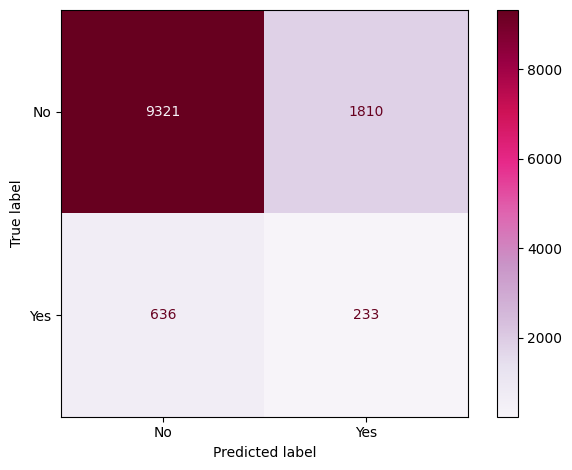

Confusion Matrix for XGBoost:


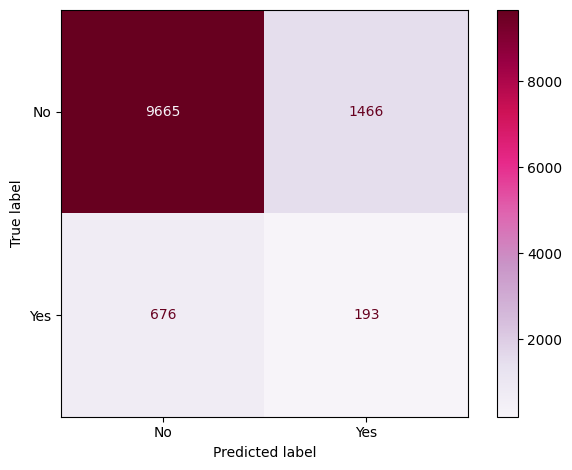

Confusion Matrix for Random Forest:


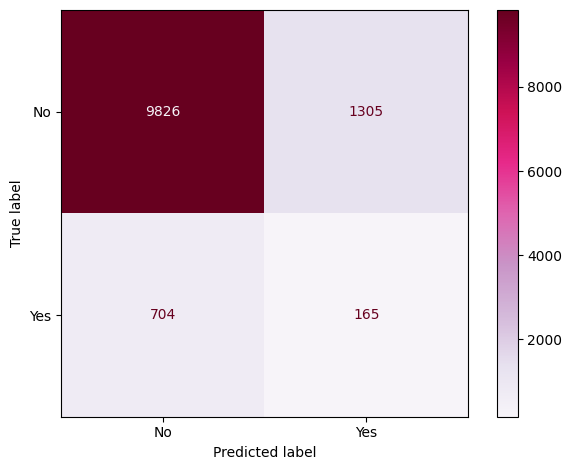

In [ ]:
# plot confusion matrices
for idx, row in results_enn_df.iterrows():
    print(f'Confusion Matrix for {row["Model"]}:')
    disp = ConfusionMatrixDisplay(confusion_matrix=row['Confusion Matrix'], display_labels=['No', 'Yes'])
    disp.plot(cmap='PuRd', values_format='d', colorbar=True)
    plt.tight_layout()
    plt.show()

#### Evaluate three tree-based models for SMOTE-Tomek data

In [ ]:
# define the classifiers
classifiers = {
    'Decision Tree': DecisionTreeClassifier(random_state=seed),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=seed, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=200, random_state=seed, n_jobs=-1)
}

#initialise the results list
results_tomek = []

# Map boolean labels to numerical for ROC AUC calculation
label_mapping = {False: 0, True: 1}

#iterate over each model and evaluate
for name, model in classifiers.items():
    model.fit(X_train_tomek, y_train_tomek)
    predictions = model.predict(X_test)

    # precision, recall, f1-score, and support
    report = classification_report(y_test, predictions, output_dict=True, zero_division='warn')
    precision = report['True']['precision']
    recall = report['True']['recall']
    f1_score = report['True']['f1-score']
    support = report['True']['support'] # Support for the positive class

    # Convert y_test to numerical for roc_auc_score (y_test is boolean)
    y_test_numeric = y_test.map(label_mapping)
    # predictions are already numerical (0s and 1s), so directly convert to Series
    predictions_numeric = pd.Series(predictions)
    # Use numerical labels for roc_auc_score
    roc_auc = roc_auc_score(y_test_numeric, predictions_numeric)

    # full classification report
    cr = classification_report(y_test, predictions)

    # confusion matrix
    cm = confusion_matrix(y_test, predictions)

    # Append the results_tomek to the list

    results_tomek.append({
        'Model': name,
        'Precision': precision,
        'Recall': recall,
        'F1 score': f1_score,
        'Support': support,
        'ROC AUC': roc_auc,
        'Classification Report': cr,
        'Confusion Matrix': cm
    })


##### Classification reports and confusion matrices

In [ ]:
#classification report
print('Classification Model Performance:')
results_tomek_df = pd.DataFrame(results_tomek).sort_values('F1 score', ascending=False)
print(results_tomek_df.iloc[:,0:6].round(4))
print()

for idx, row in results_tomek_df.iterrows():
    print(f'Classification Report for {row["Model"]}:')
    print(row['Classification Report'])
    print()

Classification Model Performance:
           Model  Precision  Recall  F1 score  Support  ROC AUC
2        XGBoost     0.1322  0.1507    0.1409    869.0   0.5367
0  Decision Tree     0.1132  0.1841    0.1402    869.0   0.5357
1  Random Forest     0.1293  0.1461    0.1372    869.0   0.5347

Classification Report for XGBoost:
              precision    recall  f1-score   support

       False       0.93      0.92      0.93     11131
        True       0.13      0.15      0.14       869

    accuracy                           0.87     12000
   macro avg       0.53      0.54      0.53     12000
weighted avg       0.87      0.87      0.87     12000


Classification Report for Decision Tree:
              precision    recall  f1-score   support

       False       0.93      0.89      0.91     11131
        True       0.11      0.18      0.14       869

    accuracy                           0.84     12000
   macro avg       0.52      0.54      0.52     12000
weighted avg       0.87      0.84

Confusion Matrix for XGBoost:


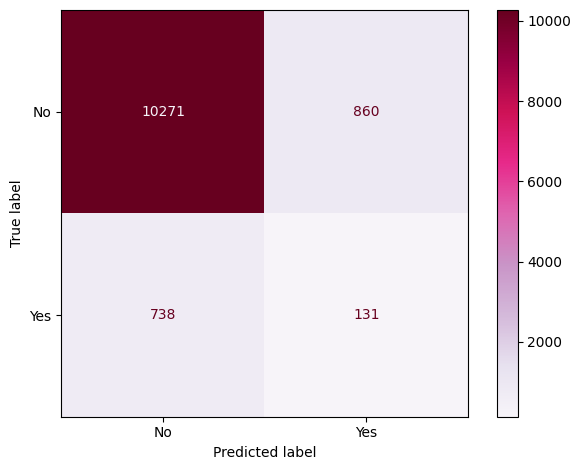

Confusion Matrix for Decision Tree:


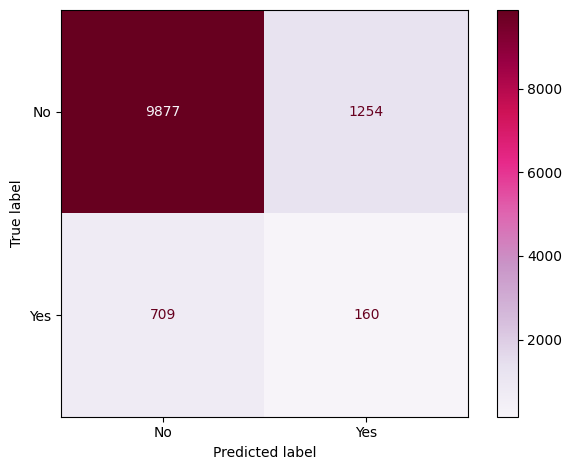

Confusion Matrix for Random Forest:


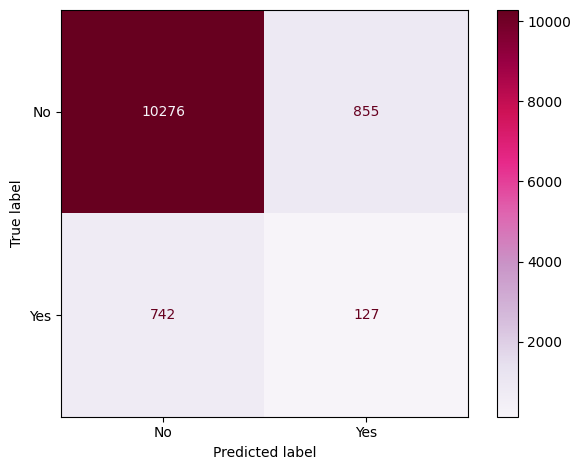

In [ ]:
# plot confusion matrices
for idx, row in results_tomek_df.iterrows():
    print(f'Confusion Matrix for {row["Model"]}:')
    disp = ConfusionMatrixDisplay(confusion_matrix=row['Confusion Matrix'], display_labels=['No', 'Yes'])
    disp.plot(cmap='PuRd', values_format='d', colorbar=True)
    plt.tight_layout()
    plt.show()

#### Evaluate three tree-based models for Random Under Sampler data

In [ ]:
# define the classifiers
classifiers = {
    'Decision Tree': DecisionTreeClassifier(random_state=seed),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=seed, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=200, random_state=seed, n_jobs=-1)
}

#initialise the results list
results_rus = []

# Map boolean labels to numerical for ROC AUC calculation
label_mapping = {False: 0, True: 1}

#iterate over each model and evaluate
for name, model in classifiers.items():
    model.fit(X_train_rus, y_train_rus)
    predictions = model.predict(X_test)

    # precision, recall, f1-score, and support
    report = classification_report(y_test, predictions, output_dict=True, zero_division='warn')
    precision = report['True']['precision']
    recall = report['True']['recall']
    f1_score = report['True']['f1-score']
    support = report['True']['support'] # Support for the positive class

    # Convert y_test to numerical for roc_auc_score (y_test is boolean)
    y_test_numeric = y_test.map(label_mapping)
    # predictions are already numerical (0s and 1s), so directly convert to Series
    predictions_numeric = pd.Series(predictions)
    # Use numerical labels for roc_auc_score
    roc_auc = roc_auc_score(y_test_numeric, predictions_numeric)

    # full classification report
    cr = classification_report(y_test, predictions)

    # confusion matrix
    cm = confusion_matrix(y_test, predictions)

    # Append the results_rus to the list

    results_rus.append({
        'Model': name,
        'Precision': precision,
        'Recall': recall,
        'F1 score': f1_score,
        'Support': support,
        'ROC AUC': roc_auc,
        'Classification Report': cr,
        'Confusion Matrix': cm
    })


##### Classification reports and confusion matrices

In [ ]:
#classification report
print('Classification Model Performance:')
results_rus_df = pd.DataFrame(results_rus).sort_values('F1 score', ascending=False)
print(results_rus_df.iloc[:,0:6].round(4))
print()

for idx, row in results_rus_df.iterrows():
    print(f'Classification Report for {row["Model"]}:')
    print(row['Classification Report'])
    print()

Classification Model Performance:
           Model  Precision  Recall  F1 score  Support  ROC AUC
1  Random Forest     0.0882  0.5455    0.1518    869.0   0.5525
2        XGBoost     0.0847  0.5167    0.1456    869.0   0.5405
0  Decision Tree     0.0822  0.5420    0.1428    869.0   0.5349

Classification Report for Random Forest:
              precision    recall  f1-score   support

       False       0.94      0.56      0.70     11131
        True       0.09      0.55      0.15       869

    accuracy                           0.56     12000
   macro avg       0.51      0.55      0.43     12000
weighted avg       0.88      0.56      0.66     12000


Classification Report for XGBoost:
              precision    recall  f1-score   support

       False       0.94      0.56      0.70     11131
        True       0.08      0.52      0.15       869

    accuracy                           0.56     12000
   macro avg       0.51      0.54      0.43     12000
weighted avg       0.88      0.56

Confusion Matrix for Random Forest:


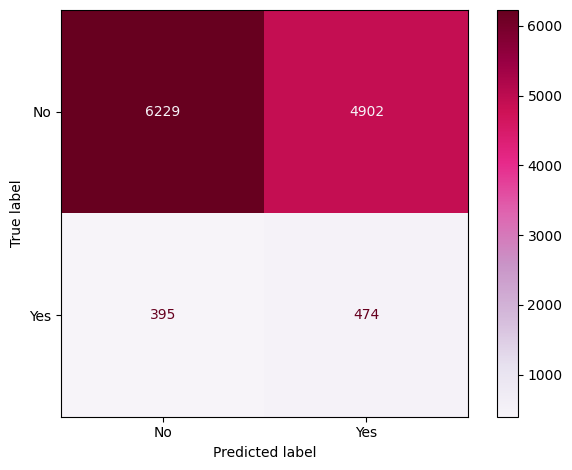

Confusion Matrix for XGBoost:


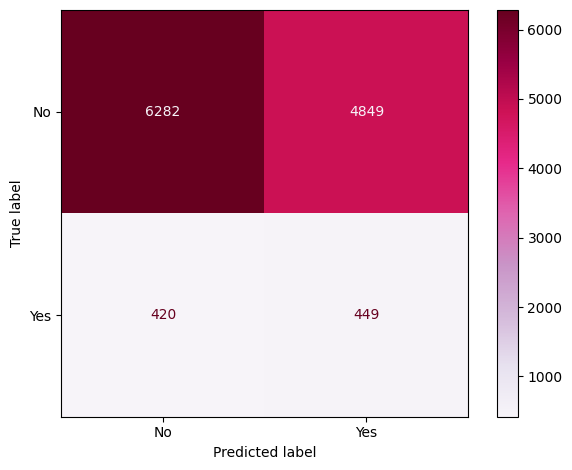

Confusion Matrix for Decision Tree:


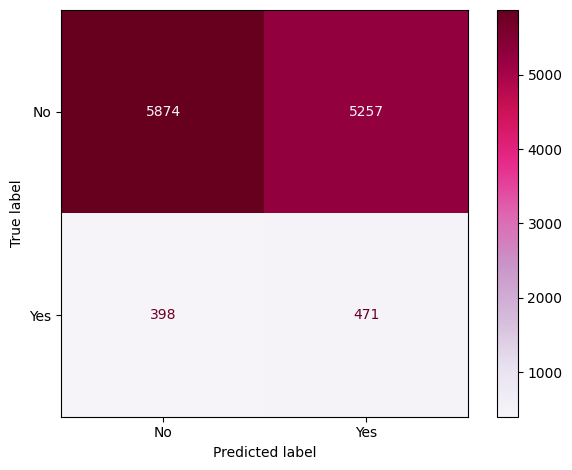

In [ ]:
# plot confusion matrices
for idx, row in results_rus_df.iterrows():
    print(f'Confusion Matrix for {row["Model"]}:')
    disp = ConfusionMatrixDisplay(confusion_matrix=row['Confusion Matrix'], display_labels=['No', 'Yes'])
    disp.plot(cmap='PuRd', values_format='d', colorbar=True)
    plt.tight_layout()
    plt.show()